# LitePhospho v4 — Q1 evidence pipeline

**What changed vs v3 (and why it matters for a Q1 paper):**

1. **Homology-aware split (MMseqs2, 30% identity).** Proteins are clustered and whole clusters go to train/val/test. This is the leakage-free evaluation your proposal promised — and the central novelty of the paper.
2. **Baselines under the SAME split:** Logistic Regression, Linear SVM, Random Forest, XGBoost, plain CNN. A Q1 reviewer rejects without these.
3. **Compact 1D CNN (<1M params)** that preserves window position (flatten, not global pooling) — keeps it CPU-deployable while capturing position-specific motifs.
4. **AUPRC as the primary metric + ECE calibration** (your proposal, Limitation #6).
5. **Faithful explanations** via Integrated Gradients + a deletion test (not just pretty pictures).
6. **Green-computing metrics:** CPU latency, model size, energy + CO2 estimate.

Run top to bottom. Training the hero model is the only slow part (~1-2 h on T4).

In [1]:
# LitePhospho v4 - LEAN + DETERMINISTIC Kaggle pipeline.
# No Colab, no checkpoints/resume, no memory cruft. Seeded for reproducible results.
import os
assert os.path.exists('/kaggle/input'), 'Kaggle-only notebook: attach the datasets first.'
print('Kaggle environment OK.')

Kaggle environment OK.


## Segment 1 — Paths

In [2]:
from pathlib import Path
RAW_BASE  = Path('/kaggle/input/datasets/mdkarimulislam/bioinformatics-thesis-project/bio_project')
PTMD_PATH = Path('/kaggle/input/datasets/mdkarimulislam/total-ptm-disease/Total.txt')
WORK_BASE = Path('/kaggle/working')
EPSD_DIR = RAW_BASE/'epsd_human'; UNIPROT_DIR = RAW_BASE/'uniprot'
PROC_DIR = WORK_BASE/'data/processed'; SAVE_DIR = WORK_BASE
for d in [WORK_BASE, PROC_DIR]: d.mkdir(parents=True, exist_ok=True)
print('RAW_BASE :', RAW_BASE, '| exists:', RAW_BASE.exists())
print('SAVE_DIR :', SAVE_DIR, '(figures + FINAL files go here)')
print('PTMD     :', PTMD_PATH, '| exists:', PTMD_PATH.exists())

RAW_BASE : /kaggle/input/datasets/mdkarimulislam/bioinformatics-thesis-project/bio_project | exists: True
SAVE_DIR : /kaggle/working (figures + FINAL files go here)
PTMD     : /kaggle/input/datasets/mdkarimulislam/total-ptm-disease/Total.txt | exists: True


In [3]:
# ===== DEFINITIONS — imports, constants, classes, helpers. NO heavy compute. =====
# Run this once near the top. On reconnect: [mount] -> [Paths] -> [this cell] -> [RESUME] -> continue.
import os, re, copy, time, gc, pickle
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, accuracy_score,
                             confusion_matrix, roc_curve, precision_recall_curve)

# ---- constants / encoders ----
WINDOW = 31; HALF = WINDOW // 2
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWYX')
vocab = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
idx_to_aa = {i: aa for aa, i in vocab.items()}
PAD_IDX = vocab['X']; NAA = len(AMINO_ACIDS); BATCH = 512
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def encode_window(w):
    return torch.tensor([vocab.get(a, PAD_IDX) for a in w.upper()], dtype=torch.long)

class PhosphoDataset(Dataset):
    def __init__(self, recs):
        self.X = torch.stack([encode_window(r[2]) for r in recs])
        self.y = torch.tensor([r[3] for r in recs], dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# ---- model classes ----
class PlainCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.conv = nn.Conv1d(embed_dim, 128, 5, padding=2)
        self.fc1 = nn.Linear(128, 64); self.fc2 = nn.Linear(64, 1); self.drop = nn.Dropout(0.3)
    def forward(self, x, embedded=None):
        emb = embedded.transpose(1,2) if embedded is not None else self.embedding(x).transpose(1,2)
        h = F.relu(self.conv(emb)).max(dim=2).values
        h = self.drop(F.relu(self.fc1(h)))
        return self.fc2(h).squeeze(1)

class LitePhospho(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.c3 = nn.Conv1d(embed_dim, 64, 3, padding=1)
        self.c5 = nn.Conv1d(embed_dim, 64, 5, padding=2)
        self.c7 = nn.Conv1d(embed_dim, 64, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(192)
        self.conv2 = nn.Conv1d(192, 64, 3, padding=1); self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 32, 1); self.bn3 = nn.BatchNorm1d(32)
        self.fc1 = nn.Linear(32*WINDOW, 256); self.bn4 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 64); self.fc3 = nn.Linear(64, 1); self.drop = nn.Dropout(dropout)
    def _trunk(self, emb):
        h = torch.cat([F.relu(self.c3(emb)), F.relu(self.c5(emb)), F.relu(self.c7(emb))], dim=1)
        h = self.drop(self.bn1(h))
        h = self.drop(self.bn2(F.relu(self.conv2(h))))
        h = self.drop(self.bn3(F.relu(self.conv3(h))))
        h = h.flatten(1)
        x = self.drop(F.relu(self.bn4(self.fc1(h))))
        x = self.drop(F.relu(self.fc2(x)))
        return self.fc3(x).squeeze(1)
    def forward(self, x, embedded=None):
        emb = embedded.transpose(1,2) if embedded is not None else self.embedding(x).transpose(1,2)
        return self._trunk(emb)

class DeepPhosNet(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, growth=32, kernels=(1,3,5,7,9), dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.blocks = nn.ModuleList()
        for k in kernels:
            layers, in_c = nn.ModuleList(), embed_dim
            for _ in range(3):
                layers.append(nn.Conv1d(in_c, growth, k, padding=k//2)); in_c += growth
            self.blocks.append(layers)
        ch = len(kernels) * (embed_dim + 3*growth)
        self.reduce = nn.Conv1d(ch, 32, 1); self.bn = nn.BatchNorm1d(32)
        self.fc1 = nn.Linear(32*WINDOW, 128); self.fc2 = nn.Linear(128, 1); self.drop = nn.Dropout(dropout)
    def forward(self, x, embedded=None):
        emb = embedded.transpose(1,2) if embedded is not None else self.embedding(x).transpose(1,2)
        outs = []
        for layers in self.blocks:
            h = emb
            for conv in layers:
                h = torch.cat([h, F.relu(conv(h))], dim=1)
            outs.append(h)
        z = torch.cat(outs, dim=1)
        z = self.drop(F.relu(self.bn(self.reduce(z)))).flatten(1)
        z = self.drop(F.relu(self.fc1(z)))
        return self.fc2(z).squeeze(1)

class MusiteDeepNet(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, ch=128, heads=4, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.conv1 = nn.Conv1d(embed_dim, ch, 5, padding=2)
        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1); self.bn = nn.BatchNorm1d(ch)
        self.attn = nn.MultiheadAttention(ch, heads, dropout=dropout, batch_first=True)
        self.fc1 = nn.Linear(ch*WINDOW, 128); self.fc2 = nn.Linear(128, 1); self.drop = nn.Dropout(dropout)
    def forward(self, x, embedded=None):
        emb = embedded.transpose(1,2) if embedded is not None else self.embedding(x).transpose(1,2)
        h = self.bn(F.relu(self.conv2(F.relu(self.conv1(emb))))).transpose(1,2)
        a,_ = self.attn(h, h, h)
        z = self.drop(a).flatten(1)
        z = self.drop(F.relu(self.fc1(z)))
        return self.fc2(z).squeeze(1)

class ESMHead2(nn.Module):
    def __init__(self, d, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(256,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(64,1))
    def forward(self, x): return self.net(x).squeeze(1)

# ---- helper functions ----
results = {}
def record(name, yt, scores, preds):
    results[name] = {'ROC_AUC': roc_auc_score(yt, scores),
                     'PR_AUC': average_precision_score(yt, scores), 'F1': f1_score(yt, preds)}
    print(f"{name:22s} ROC-AUC={results[name]['ROC_AUC']:.4f}  PR-AUC={results[name]['PR_AUC']:.4f}  F1={results[name]['F1']:.4f}")

def deep_scores(model, loader):
    model.eval(); ys, ss = [], []
    with torch.no_grad():
        for bx, by in loader:
            ss.append(torch.sigmoid(model(bx.to(device))).cpu()); ys.append(by)
    return torch.cat(ys).numpy(), torch.cat(ss).numpy()

def onehot_matrix(recs):
    n = len(recs); X = np.zeros((n, WINDOW*NAA), np.float32); y = np.zeros(n, np.int64)
    for i, r in enumerate(recs):
        for j, aa in enumerate(r[2]): X[i, j*NAA + vocab.get(aa, PAD_IDX)] = 1.0
        y[i] = r[3]
    return X, y

def score_windows(win_list, bs=4096):
    hero.eval(); out = []
    with torch.no_grad():
        for k in range(0, len(win_list), bs):
            Xb = torch.stack([encode_window(w) for w in win_list[k:k+bs]]).to(device)
            out.append(torch.sigmoid(hero(Xb)).cpu().numpy())
    return np.concatenate(out) if out else np.array([])

def expected_calibration_error(y, p, bins=10):
    edges = np.linspace(0, 1, bins+1); ece = 0.0
    for i in range(bins):
        m = (p > edges[i]) & (p <= edges[i+1])
        if m.sum() > 0: ece += m.mean() * abs(y[m].mean() - p[m].mean())
    return ece

def train_model(model, epochs=60, lr=2e-4, wd=2e-3, patience=12, tag='model'):
    model = model.to(device); crit = nn.BCEWithLogitsLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', patience=6, factor=0.5, min_lr=1e-6)
    best, wait, tr_hist, va_hist = float('inf'), 0, [], []; path = SAVE_DIR/f'best_{tag}.pt'
    for ep in range(1, epochs+1):
        model.train(); tot = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device); opt.zero_grad()
            loss = crit(model(bx), by); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); tot += loss.item()*bx.size(0)
        tr = tot/len(train_ds); model.eval(); tot = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device); tot += crit(model(bx), by).item()*bx.size(0)
        va = tot/len(val_ds); sched.step(va); tr_hist.append(tr); va_hist.append(va); flag = ''
        if va < best: best, wait = va, 0; torch.save(model.state_dict(), path); flag = '  <- best'
        else:
            wait += 1
            if wait >= patience: print(f'[{tag}] ep{ep:02d} tr={tr:.4f} va={va:.4f} early stop'); break
        print(f'[{tag}] ep{ep:02d} tr={tr:.4f} va={va:.4f} lr={opt.param_groups[0]["lr"]:.1e}{flag}')
    model.load_state_dict(torch.load(path, map_location=device)); return model, tr_hist, va_hist

def train_eval_split(ModelClass, tr, va, te, epochs=80, lr=3e-4, wd=1e-3, patience=12):
    trl = DataLoader(PhosphoDataset(tr), 512, shuffle=True, num_workers=2, pin_memory=True)
    vds = PhosphoDataset(va); vall = DataLoader(vds, 1024); tel = DataLoader(PhosphoDataset(te), 1024)
    m = ModelClass(NAA).to(device); crit = nn.BCEWithLogitsLoss()
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd); best, wait, sd = 1e9, 0, None
    for ep in range(1, epochs+1):
        m.train()
        for bx, by in trl:
            bx, by = bx.to(device), by.to(device); opt.zero_grad(); crit(m(bx), by).backward(); opt.step()
        m.eval(); tot = 0.0
        with torch.no_grad():
            for bx, by in vall: bx, by = bx.to(device), by.to(device); tot += crit(m(bx), by).item()*bx.size(0)
        vl = tot/len(vds)
        if vl < best: best, wait, sd = vl, 0, copy.deepcopy(m.state_dict())
        else:
            wait += 1
            if wait >= patience: break
    m.load_state_dict(sd); m.eval(); ys, ss = [], []
    with torch.no_grad():
        for bx, by in tel: ss.append(torch.sigmoid(m(bx.to(device))).cpu()); ys.append(by)
    y = torch.cat(ys).numpy(); s = torch.cat(ss).numpy()
    return roc_auc_score(y, s), average_precision_score(y, s), s, y

def train_esm_head(Xtr, ytr, Xva, yva, seed=42, epochs=100, patience=10):
    torch.manual_seed(seed)
    trl = DataLoader(TensorDataset(torch.from_numpy(Xtr.astype(np.float32)), torch.from_numpy(ytr)), 1024, shuffle=True)
    val = DataLoader(TensorDataset(torch.from_numpy(Xva.astype(np.float32)), torch.from_numpy(yva)), 2048)
    head = ESMHead2(Xtr.shape[1]).to(device); opt = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.BCEWithLogitsLoss(); best, wait, sd = 1e9, 0, None
    for ep in range(1, epochs+1):
        head.train()
        for bx, by in trl:
            bx, by = bx.to(device), by.to(device); opt.zero_grad(); crit(head(bx), by).backward(); opt.step()
        head.eval(); tot = 0.0
        with torch.no_grad():
            for bx, by in val: bx, by = bx.to(device), by.to(device); tot += crit(head(bx), by).item()*bx.size(0)
        vl = tot/len(val.dataset)
        if vl < best: best, wait, sd = vl, 0, copy.deepcopy(head.state_dict())
        else:
            wait += 1
            if wait >= patience: break
    head.load_state_dict(sd); return head

print('definitions loaded — classes and helpers ready.')

# ===== Reproducibility: deterministic seeding (fixes run-to-run variation) =====
import os as _os, random as _random
def seed_all(seed=42):
    _os.environ['PYTHONHASHSEED'] = str(seed)
    _random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_all(42)
print('deterministic seeding ON (cudnn.deterministic=True, benchmark=False, seed=42)')


device: cuda
definitions loaded — classes and helpers ready.
deterministic seeding ON (cudnn.deterministic=True, benchmark=False, seed=42)


## Segment 2 — Parse EPSD + UniProt FASTA

In [4]:
import pandas as pd, re, numpy as np

df = pd.read_csv(EPSD_DIR / 'Homo sapiens.txt', sep=None, engine='python')
print('EPSD shape:', df.shape, '| columns:', list(df.columns))

acc_regex = re.compile(r'^[OPQ][0-9][A-Z0-9]{3}[0-9](?:-\d+)?$|^[A-NR-Z][0-9]{5}(?:-\d+)?$', re.I)
def pick_acc_column(df):
    best_col, best_hits = None, -1
    for c in df.columns:
        hits = df[c].astype(str).str.strip().str.match(acc_regex).sum()
        if hits > best_hits:
            best_hits, best_col = hits, c
    return best_col
acc_col = pick_acc_column(df)
pos_col = next(c for c in df.columns if 'position' in c.lower())
res_col = next(c for c in df.columns if c.lower() in {'residue','aa','modified residue'})

epsd = df[[acc_col, res_col, pos_col]].copy()
epsd.columns = ['acc_raw', 'residue', 'pos']
epsd['acc']     = epsd['acc_raw'].astype(str).str.split('-').str[0]
epsd['pos']     = epsd['pos'].astype(int)
epsd['residue'] = epsd['residue'].astype(str).str.upper()
epsd = epsd[epsd['residue'].isin(list('STY'))].drop_duplicates(['acc','pos']).copy()
print('EPSD S/T/Y rows after de-dup:', len(epsd))

EPSD shape: (1071725, 6) | columns: ['EPSD ID', 'UniProt ID', 'AA', 'Position', 'Source', 'Reference']
EPSD S/T/Y rows after de-dup: 871982


In [5]:
seq_dict = {}
with open(UNIPROT_DIR / 'uniprotkb.fasta') as f:
    acc, buf = None, []
    for line in f:
        line = line.strip()
        if line.startswith('>'):
            if acc:
                seq_dict[acc] = ''.join(buf)
            parts = line[1:].split('|')
            acc = parts[1] if len(parts) >= 2 else parts[0].split()[0]
            buf = []
        else:
            buf.append(line)
    if acc:
        seq_dict[acc] = ''.join(buf)
print(f'Loaded {len(seq_dict):,} UniProt sequences')

Loaded 20,405 UniProt sequences


## Segment 3 — Build windows (positives + 1:1 negatives)

In [6]:
WINDOW = 31
HALF   = WINDOW // 2

epsd_known = epsd[epsd['acc'].isin(seq_dict)].copy()
epsd_known['pos0'] = epsd_known['pos'] - 1

pos_records = []
for acc, grp in epsd_known.groupby('acc'):
    seq    = seq_dict[acc]
    padded = 'X'*HALF + seq + 'X'*HALF
    for p, r in zip(grp['pos0'].astype(int).values, grp['residue'].values):
        if 0 <= p < len(seq) and seq[p] == r:   # FIX: residue must match EPSD annotation
            w = padded[p:p+WINDOW]
            if len(w) == WINDOW:
                pos_records.append((acc, p, w, 1))
print(f'Positive windows: {len(pos_records):,}')

pos_set      = {(a, p) for a, p, _, _ in pos_records}
pos_proteins = {a for a, _, _, _ in pos_records}

neg_records = []
for acc in pos_proteins:
    seq    = seq_dict[acc]
    padded = 'X'*HALF + seq + 'X'*HALF
    for i, aa in enumerate(seq):
        if aa in 'STY' and (acc, i) not in pos_set:
            w = padded[i:i+WINDOW]
            if len(w) == WINDOW:
                neg_records.append((acc, i, w, 0))
print(f'Negative windows (raw): {len(neg_records):,}')

rng = np.random.default_rng(42)
neg_idx = rng.choice(len(neg_records), size=min(len(pos_records), len(neg_records)), replace=False)
neg_bal = [neg_records[i] for i in neg_idx]
all_records = pos_records + neg_bal
print(f'Balanced total: {len(all_records):,}  (pos {len(pos_records):,} / neg {len(neg_bal):,})')

Positive windows: 577,608
Negative windows (raw): 1,272,526
Balanced total: 1,155,216  (pos 577,608 / neg 577,608)


## Segment 4 — Homology-aware split (MMseqs2, 30% identity)

**This is the core of the paper.** We cluster every protein at 30% sequence identity and
assign whole clusters to train/val/test, so no test protein is >30% similar to any training
protein. This is what 'leakage-free' actually means — a plain protein-level split does NOT
guarantee it (paralogs/homologs leak).

In [7]:
import os, subprocess

# One-time download of the MMseqs2 static binary
if not os.path.exists('mmseqs/bin/mmseqs'):
    os.system('wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz && tar xzf mmseqs-linux-avx2.tar.gz')
MMSEQS = os.path.abspath('mmseqs/bin/mmseqs')
print('MMseqs2 binary:', MMSEQS, '| exists:', os.path.exists(MMSEQS))

# Write FASTA of proteins that have at least one positive site
clust_fasta = str(PROC_DIR / 'pos_proteins.fasta')
with open(clust_fasta, 'w') as f:
    for acc in sorted(pos_proteins):
        f.write(f'>{acc}\n{seq_dict[acc]}\n')

out_prefix = str(PROC_DIR / 'clust')
tmp_dir    = '/tmp/mmseqs_tmp' # Changed to a local temporary directory
os.makedirs(tmp_dir, exist_ok=True) # Ensure the temporary directory exists
cmd = f'{MMSEQS} easy-cluster {clust_fasta} {out_prefix} {tmp_dir} --min-seq-id 0.3 -c 0.5 --cov-mode 1 -v 1'
print('Running:', cmd)

# Use subprocess.run to capture output and errors for better debugging
try:
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, check=True)
    print("MMseqs2 stdout:", result.stdout)
    if result.stderr:
        print("MMseqs2 stderr:", result.stderr)
except subprocess.CalledProcessError as e:
    print(f"MMseqs2 command failed with exit code {e.returncode}")
    print(f"stdout: {e.stdout}")
    print(f"stderr: {e.stderr}")
    # Re-raise or handle the error as appropriate for your workflow
    raise

prot2cluster = {}
with open(out_prefix + '_cluster.tsv') as f:
    for line in f:
        rep, mem = line.strip().split('\t')
        prot2cluster[mem] = rep
clusters = sorted(set(prot2cluster.values()))
print(f'{len(pos_proteins):,} proteins -> {len(clusters):,} clusters at 30% identity')


MMseqs2 binary: /kaggle/working/mmseqs/bin/mmseqs | exists: True
Running: /kaggle/working/mmseqs/bin/mmseqs easy-cluster /kaggle/working/data/processed/pos_proteins.fasta /kaggle/working/data/processed/clust /tmp/mmseqs_tmp --min-seq-id 0.3 -c 0.5 --cov-mode 1 -v 1
MMseqs2 stdout: 
19,625 proteins -> 9,870 clusters at 30% identity


In [8]:
from sklearn.model_selection import train_test_split

train_cl, temp_cl = train_test_split(clusters, test_size=0.30, random_state=42)
val_cl,   test_cl = train_test_split(temp_cl,   test_size=0.50, random_state=42)
train_cl, val_cl, test_cl = set(train_cl), set(val_cl), set(test_cl)

def split_of(acc):
    c = prot2cluster.get(acc)
    if c in train_cl: return 'train'
    if c in val_cl:   return 'val'
    if c in test_cl:  return 'test'
    return None

buckets = {'train': [], 'val': [], 'test': []}
for r in all_records:
    s = split_of(r[0])
    if s:
        buckets[s].append(r)
train_recs, val_recs, test_recs = buckets['train'], buckets['val'], buckets['test']

def pos_frac(recs):
    return np.mean([r[3] for r in recs]) if recs else 0
print(f'Train: {len(train_recs):,} (pos {pos_frac(train_recs):.2%})')
print(f'Val  : {len(val_recs):,} (pos {pos_frac(val_recs):.2%})')
print(f'Test : {len(test_recs):,} (pos {pos_frac(test_recs):.2%})')
print('Cluster overlap check (must all be 0):',
      len(train_cl & val_cl), len(train_cl & test_cl), len(val_cl & test_cl))

Train: 807,583 (pos 49.69%)
Val  : 175,019 (pos 51.05%)
Test : 172,614 (pos 50.41%)
Cluster overlap check (must all be 0): 0 0 0


## Segment 5 — Encoding, datasets, dataloaders

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWYX')
vocab     = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
idx_to_aa = {i: aa for aa, i in vocab.items()}
PAD_IDX   = vocab['X']
NAA       = len(AMINO_ACIDS)

def encode_window(w):
    return torch.tensor([vocab.get(a, PAD_IDX) for a in w.upper()], dtype=torch.long)

class PhosphoDataset(Dataset):
    def __init__(self, recs):
        self.X = torch.stack([encode_window(r[2]) for r in recs])
        self.y = torch.tensor([r[3] for r in recs], dtype=torch.float32)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds, val_ds, test_ds = PhosphoDataset(train_recs), PhosphoDataset(val_recs), PhosphoDataset(test_recs)
BATCH = 512
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print('Datasets ready.')

Datasets ready.


## Segment 6 — Classical baselines (same split, one-hot features)

Train set is subsampled to 150k for the CPU classical models (noted in the paper);
they are all evaluated on the **full** held-out test set for a fair comparison.

In [10]:
def onehot_matrix(recs):
    n = len(recs)
    X = np.zeros((n, WINDOW * NAA), dtype=np.float32)
    y = np.zeros(n, dtype=np.int64)
    for i, r in enumerate(recs):
        for j, aa in enumerate(r[2]):
            X[i, j*NAA + vocab.get(aa, PAD_IDX)] = 1.0
        y[i] = r[3]
    return X, y

sub = rng.choice(len(train_recs), size=min(150_000, len(train_recs)), replace=False)
train_sub = [train_recs[i] for i in sub]
Xtr, ytr = onehot_matrix(train_sub)
Xte, yte = onehot_matrix(test_recs)
print('Feature matrices:', Xtr.shape, Xte.shape)

Feature matrices: (150000, 651) (172614, 651)


In [11]:
!pip install xgboost -q
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import xgboost as xgb

results = {}
def record(name, yt, scores, preds):
    results[name] = {
        'ROC_AUC': roc_auc_score(yt, scores),
        'PR_AUC' : average_precision_score(yt, scores),
        'F1'     : f1_score(yt, preds),
    }
    print(f"{name:20s} ROC-AUC={results[name]['ROC_AUC']:.4f}  PR-AUC={results[name]['PR_AUC']:.4f}  F1={results[name]['F1']:.4f}")

lr = LogisticRegression(max_iter=300, n_jobs=-1).fit(Xtr, ytr)
p = lr.predict_proba(Xte)[:, 1];  record('LogisticRegression', yte, p, (p >= 0.5).astype(int))

svm = LinearSVC().fit(Xtr, ytr)
s = svm.decision_function(Xte);   record('LinearSVM', yte, s, (s >= 0).astype(int))

rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42).fit(Xtr, ytr)
p = rf.predict_proba(Xte)[:, 1];  record('RandomForest', yte, p, (p >= 0.5).astype(int))

xgbc = xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                         subsample=0.8, n_jobs=-1, eval_metric='logloss').fit(Xtr, ytr)
p = xgbc.predict_proba(Xte)[:, 1]; record('XGBoost', yte, p, (p >= 0.5).astype(int))

LogisticRegression   ROC-AUC=0.7249  PR-AUC=0.7059  F1=0.6660
LinearSVM            ROC-AUC=0.7244  PR-AUC=0.7059  F1=0.6656
RandomForest         ROC-AUC=0.7117  PR-AUC=0.7017  F1=0.6513
XGBoost              ROC-AUC=0.7280  PR-AUC=0.7181  F1=0.6665


## Segment 7 — Models: plain-CNN baseline + lightweight hero (<1M params)

In [12]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

class PlainCNN(nn.Module):
    """Minimal CNN baseline (the 'plain CNN' from your work division)."""
    def __init__(self, vocab_size, embed_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.conv = nn.Conv1d(embed_dim, 128, kernel_size=5, padding=2)
        self.fc1  = nn.Linear(128, 64)
        self.fc2  = nn.Linear(64, 1)
        self.drop = nn.Dropout(0.3)
    def forward(self, x, embedded=None):
        emb = (embedded.transpose(1,2) if embedded is not None
               else self.embedding(x).transpose(1,2))
        h = F.relu(self.conv(emb)).max(dim=2).values
        h = self.drop(F.relu(self.fc1(h)))
        return self.fc2(h).squeeze(1)

class LitePhospho(nn.Module):
    """Lightweight CNN that PRESERVES window position (flatten, not global-pool).
    Global pooling discarded *where* a motif occurred, which is why the pooled
    version lost to logistic-regression-on-one-hot. Flattening keeps position so
    the model learns position-specific motifs + residue interactions a linear
    model cannot. ~0.44M params, still <1M and CPU-deployable.
    forward() accepts pre-embedded input for Captum.
    """
    def __init__(self, vocab_size, embed_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        # Multi-scale motif block (length preserved)
        self.c3 = nn.Conv1d(embed_dim, 64, 3, padding=1)
        self.c5 = nn.Conv1d(embed_dim, 64, 5, padding=2)
        self.c7 = nn.Conv1d(embed_dim, 64, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(192)
        self.conv2 = nn.Conv1d(192, 64, 3, padding=1); self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 32, 1);             self.bn3 = nn.BatchNorm1d(32)
        flat = 32 * WINDOW
        self.fc1 = nn.Linear(flat, 256); self.bn4 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 1)
        self.drop = nn.Dropout(dropout)
    def _trunk(self, emb):
        h = torch.cat([F.relu(self.c3(emb)), F.relu(self.c5(emb)), F.relu(self.c7(emb))], dim=1)
        h = self.drop(self.bn1(h))
        h = self.drop(self.bn2(F.relu(self.conv2(h))))
        h = self.drop(self.bn3(F.relu(self.conv3(h))))   # [B, 32, L]
        h = h.flatten(1)                                  # [B, 32*L]  <- keeps WHERE features are
        x = self.drop(F.relu(self.bn4(self.fc1(h))))
        x = self.drop(F.relu(self.fc2(x)))
        return self.fc3(x).squeeze(1)
    def forward(self, x, embedded=None):
        emb = (embedded.transpose(1,2) if embedded is not None
               else self.embedding(x).transpose(1,2))
        return self._trunk(emb)

hero = LitePhospho(NAA).to(device)
n_params = sum(p.numel() for p in hero.parameters() if p.requires_grad)
print(f'LitePhospho trainable params: {n_params:,}  (<1M target: {"OK" if n_params < 1_000_000 else "OVER"})')

Device: cuda
LitePhospho trainable params: 436,577  (<1M target: OK)


## Segment 8 — Training loop (reused for both deep models)

In [13]:
def train_model(model, epochs=60, lr=2e-4, wd=2e-3, patience=12, tag='model'):
    model = model.to(device)
    crit = nn.BCEWithLogitsLoss()
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=6, factor=0.5, min_lr=1e-6)
    best, wait, tr_hist, va_hist = float('inf'), 0, [], []
    path = SAVE_DIR / f'best_{tag}.pt'
    for ep in range(1, epochs+1):
        model.train(); tot = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad()
            loss = crit(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tot += loss.item()*bx.size(0)
        tr = tot/len(train_ds)
        model.eval(); tot = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                tot += crit(model(bx), by).item()*bx.size(0)
        va = tot/len(val_ds)
        sched.step(va); tr_hist.append(tr); va_hist.append(va)
        flag = ''
        if va < best:
            best, wait = va, 0
            torch.save(model.state_dict(), path); flag = '  <- best'
        else:
            wait += 1
            if wait >= patience:
                print(f'[{tag}] ep{ep:02d} tr={tr:.4f} va={va:.4f}  early stop'); break
        print(f'[{tag}] ep{ep:02d} tr={tr:.4f} va={va:.4f} lr={opt.param_groups[0]["lr"]:.1e}{flag}')
    model.load_state_dict(torch.load(path, map_location=device))
    return model, tr_hist, va_hist

In [14]:
plain = PlainCNN(NAA)
print('PlainCNN params:', sum(p.numel() for p in plain.parameters()))
plain, _, _ = train_model(plain, epochs=40, tag='plaincnn')

PlainCNN params: 50753
[plaincnn] ep01 tr=0.6051 va=0.5945 lr=2.0e-04  <- best
[plaincnn] ep02 tr=0.5879 va=0.5921 lr=2.0e-04  <- best
[plaincnn] ep03 tr=0.5821 va=0.5914 lr=2.0e-04  <- best
[plaincnn] ep04 tr=0.5784 va=0.5920 lr=2.0e-04
[plaincnn] ep05 tr=0.5755 va=0.5938 lr=2.0e-04
[plaincnn] ep06 tr=0.5734 va=0.5935 lr=2.0e-04
[plaincnn] ep07 tr=0.5715 va=0.5955 lr=2.0e-04
[plaincnn] ep08 tr=0.5700 va=0.5950 lr=2.0e-04
[plaincnn] ep09 tr=0.5686 va=0.5964 lr=2.0e-04
[plaincnn] ep10 tr=0.5673 va=0.5968 lr=1.0e-04
[plaincnn] ep11 tr=0.5639 va=0.5965 lr=1.0e-04
[plaincnn] ep12 tr=0.5627 va=0.5992 lr=1.0e-04
[plaincnn] ep13 tr=0.5622 va=0.6002 lr=1.0e-04
[plaincnn] ep14 tr=0.5615 va=0.5992 lr=1.0e-04
[plaincnn] ep15 tr=0.5612 va=0.5994  early stop


In [15]:
import time
_t0 = time.time()
# Less regularization (wd 1e-4) + higher LR + train longer — fixes the underfitting
hero, tr_hist, va_hist = train_model(hero, epochs=150, lr=3e-4, wd=1e-4, patience=20, tag='litephospho')
TRAIN_SECONDS = time.time() - _t0
print(f'Hero training wall-clock: {TRAIN_SECONDS/3600:.2f} h')

[litephospho] ep01 tr=0.5902 va=0.5749 lr=3.0e-04  <- best
[litephospho] ep02 tr=0.5733 va=0.5705 lr=3.0e-04  <- best
[litephospho] ep03 tr=0.5680 va=0.5690 lr=3.0e-04  <- best
[litephospho] ep04 tr=0.5648 va=0.5675 lr=3.0e-04  <- best
[litephospho] ep05 tr=0.5625 va=0.5671 lr=3.0e-04  <- best
[litephospho] ep06 tr=0.5602 va=0.5663 lr=3.0e-04  <- best
[litephospho] ep07 tr=0.5580 va=0.5656 lr=3.0e-04  <- best
[litephospho] ep08 tr=0.5565 va=0.5667 lr=3.0e-04
[litephospho] ep09 tr=0.5547 va=0.5661 lr=3.0e-04
[litephospho] ep10 tr=0.5535 va=0.5658 lr=3.0e-04
[litephospho] ep11 tr=0.5516 va=0.5656 lr=3.0e-04  <- best
[litephospho] ep12 tr=0.5508 va=0.5675 lr=3.0e-04
[litephospho] ep13 tr=0.5499 va=0.5677 lr=3.0e-04
[litephospho] ep14 tr=0.5491 va=0.5669 lr=3.0e-04
[litephospho] ep15 tr=0.5480 va=0.5683 lr=3.0e-04
[litephospho] ep16 tr=0.5470 va=0.5674 lr=3.0e-04
[litephospho] ep17 tr=0.5462 va=0.5686 lr=3.0e-04
[litephospho] ep18 tr=0.5456 va=0.5700 lr=1.5e-04
[litephospho] ep19 tr=0.5426

## Segment 9 — Evaluate deep models, add to comparison

In [16]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, classification_report)

def deep_scores(model, loader):
    model.eval(); ys, ss = [], []
    with torch.no_grad():
        for bx, by in loader:
            ss.append(torch.sigmoid(model(bx.to(device))).cpu())
            ys.append(by)
    return torch.cat(ys).numpy(), torch.cat(ss).numpy()

yte_d, s_plain = deep_scores(plain, test_loader)
record('PlainCNN', yte_d, s_plain, (s_plain >= 0.5).astype(int))

yte_d, s_hero = deep_scores(hero, test_loader)
record('LitePhospho (ours)', yte_d, s_hero, (s_hero >= 0.5).astype(int))

print('\nLitePhospho detailed report:')
print(classification_report(yte_d, (s_hero >= 0.5).astype(int),
                            target_names=['Non-phospho', 'Phospho']))
print(confusion_matrix(yte_d, (s_hero >= 0.5).astype(int)))

PlainCNN             ROC-AUC=0.7401  PR-AUC=0.7302  F1=0.6812
LitePhospho (ours)   ROC-AUC=0.7694  PR-AUC=0.7650  F1=0.6974

LitePhospho detailed report:
              precision    recall  f1-score   support

 Non-phospho       0.69      0.70      0.69     85596
     Phospho       0.70      0.70      0.70     87018

    accuracy                           0.70    172614
   macro avg       0.70      0.70      0.70    172614
weighted avg       0.70      0.70      0.70    172614

[[59630 25966]
 [26521 60497]]


## Segment 9b — ESM2 feature variant (the accuracy lever)

The from-scratch CNN is capped because it only sees raw amino-acid letters. Here we add a
second 'hero' that uses **ESM2** (a pretrained protein language model, 8M params) as a frozen
feature extractor, with a tiny MLP head. Same leakage-free split, same test set — so it drops
straight into the comparison table as **LitePhospho-ESM2**. Expect a clear jump in ROC/PR-AUC.

This gives the paper two models: the lightweight from-scratch CNN (green + explainable) and
the ESM2 variant (accuracy) — i.e. the accuracy-vs-efficiency tradeoff your proposal's WP2 promises.

In [17]:
# ===== Segment 9b — ESM2 feature variant (accuracy lever) =====
# Uses a small pretrained protein language model (ESM2-8M) as a frozen feature
# extractor: embed a +/-64 context window per site, take the centre residue's
# contextual vector (320-d), classify with a tiny MLP head. Needs internet ON.
!pip install fair-esm -q
import esm, numpy as np
from torch.utils.data import TensorDataset

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
esm_model = esm_model.eval().to(device)
ESM_LAYER, ESM_DIM, CTX = 6, 320, 64

def esm_center_features(recs, bs=256):
    feats = np.zeros((len(recs), ESM_DIM), dtype=np.float16)
    buf_data, buf_meta = [], []
    def flush():
        if not buf_data:
            return
        _, _, toks = batch_converter(buf_data)
        toks = toks.to(device)
        with torch.no_grad():
            rep = esm_model(toks, repr_layers=[ESM_LAYER])['representations'][ESM_LAYER]
        for k, (gi, center) in enumerate(buf_meta):
            feats[gi] = rep[k, center+1].float().cpu().numpy().astype(np.float16)  # +1 skips BOS
        buf_data.clear(); buf_meta.clear()
    for gi, r in enumerate(recs):
        seq = seq_dict[r[0]]; pos = r[1]
        lo = max(0, pos-CTX); hi = min(len(seq), pos+CTX+1)
        buf_data.append((str(gi), seq[lo:hi]))
        buf_meta.append((gi, pos-lo))
        if len(buf_data) >= bs:
            flush()
    flush()
    return feats

print('Extracting ESM2 features (one-time, ~5-15 min)...')
Xtr_e = esm_center_features(train_recs); ytr_e = np.array([r[3] for r in train_recs], dtype=np.float32)
Xva_e = esm_center_features(val_recs);   yva_e = np.array([r[3] for r in val_recs],   dtype=np.float32)
Xte_e = esm_center_features(test_recs);  yte_e = np.array([r[3] for r in test_recs],  dtype=np.float32)
print('ESM2 features:', Xtr_e.shape, Xva_e.shape, Xte_e.shape)

del esm_model; torch.cuda.empty_cache()   # free the extractor before training the head

class ESMHead(nn.Module):
    def __init__(self, d=ESM_DIM, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1))
    def forward(self, x):
        return self.net(x).squeeze(1)

tr_loader_e = DataLoader(TensorDataset(torch.from_numpy(Xtr_e.astype(np.float32)), torch.from_numpy(ytr_e)),
                         batch_size=1024, shuffle=True)
va_loader_e = DataLoader(TensorDataset(torch.from_numpy(Xva_e.astype(np.float32)), torch.from_numpy(yva_e)),
                         batch_size=2048)

esm_head = ESMHead().to(device)
opt  = torch.optim.AdamW(esm_head.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.BCEWithLogitsLoss()
best, wait, path = 1e9, 0, SAVE_DIR/'best_esmhead.pt'
for ep in range(1, 101):
    esm_head.train()
    for bx, by in tr_loader_e:
        bx, by = bx.to(device), by.to(device)
        opt.zero_grad(); loss = crit(esm_head(bx), by); loss.backward(); opt.step()
    esm_head.eval(); tot = 0.0
    with torch.no_grad():
        for bx, by in va_loader_e:
            bx, by = bx.to(device), by.to(device)
            tot += crit(esm_head(bx), by).item() * bx.size(0)
    va = tot/len(va_loader_e.dataset)
    if va < best:
        best, wait = va, 0; torch.save(esm_head.state_dict(), path)
    else:
        wait += 1
        if wait >= 10:
            print(f'esm-head early stop ep{ep} va={va:.4f}'); break
    if ep % 5 == 0 or ep == 1:
        print(f'esm-head ep{ep:02d} va={va:.4f}')
esm_head.load_state_dict(torch.load(path, map_location=device))

esm_head.eval()
with torch.no_grad():
    s_esm = torch.sigmoid(esm_head(torch.from_numpy(Xte_e.astype(np.float32)).to(device))).cpu().numpy()
record('LitePhospho-ESM2 (ours)', yte_e, s_esm, (s_esm >= 0.5).astype(int))
print(f'ESM2 head params: {sum(p.numel() for p in esm_head.parameters()):,}  (+ frozen ESM2-8M extractor)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.3 MB/s eta 0:00:00
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
Extracting ESM2 features (one-time, ~5-15 min)...
ESM2 features: (807583, 320) (175019, 320) (172614, 320)
esm-head ep01 va=0.5821
esm-head ep05 va=0.5796
esm-head ep10 va=0.5776
esm-head ep15 va=0.5791
esm-head early stop ep19 va=0.5813
LitePhospho-ESM2 (ours) ROC-AUC=0.7612  PR-AUC=0.7667  F1=0.6855
ESM2 head params: 99,329  (+ frozen ESM2-8M extractor)


## Segment 10 — Master comparison table (the key Q1 figure)

                         ROC_AUC  PR_AUC      F1
RandomForest              0.7117  0.7017  0.6513
LogisticRegression        0.7249  0.7059  0.6660
LinearSVM                 0.7244  0.7059  0.6656
XGBoost                   0.7280  0.7181  0.6665
PlainCNN                  0.7401  0.7302  0.6812
LitePhospho (ours)        0.7694  0.7650  0.6974
LitePhospho-ESM2 (ours)   0.7612  0.7667  0.6855


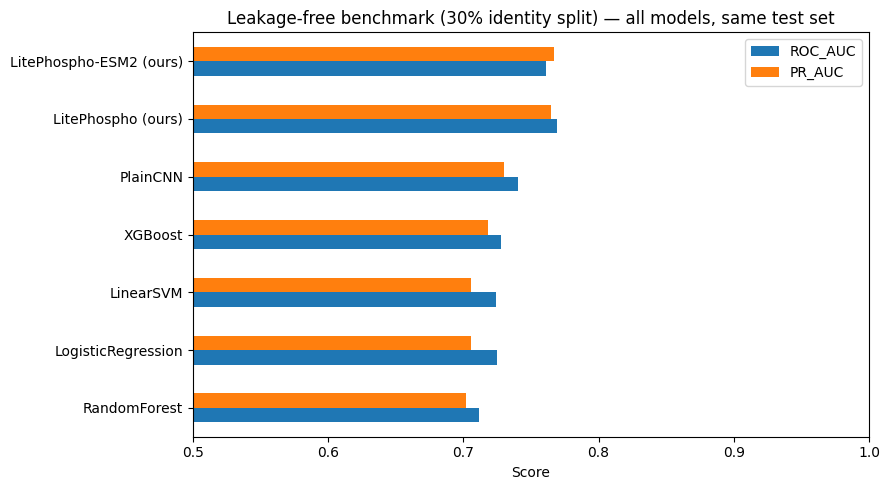

In [18]:
comp = pd.DataFrame(results).T[['ROC_AUC', 'PR_AUC', 'F1']].sort_values('PR_AUC')
comp.to_csv(SAVE_DIR / 'model_comparison.csv')
print(comp.round(4).to_string())

import matplotlib.pyplot as plt
ax = comp[['ROC_AUC', 'PR_AUC']].plot.barh(figsize=(9, 5))
ax.set_xlim(0.5, 1.0); ax.set_xlabel('Score')
ax.set_title('Leakage-free benchmark (30% identity split) — all models, same test set')
plt.tight_layout(); plt.savefig(SAVE_DIR / 'comparison_v4.png', dpi=150); plt.show()

## Segment 11 — Calibration (ECE), primary-metric curves

LitePhospho ECE: 0.0147  (lower = better calibrated)


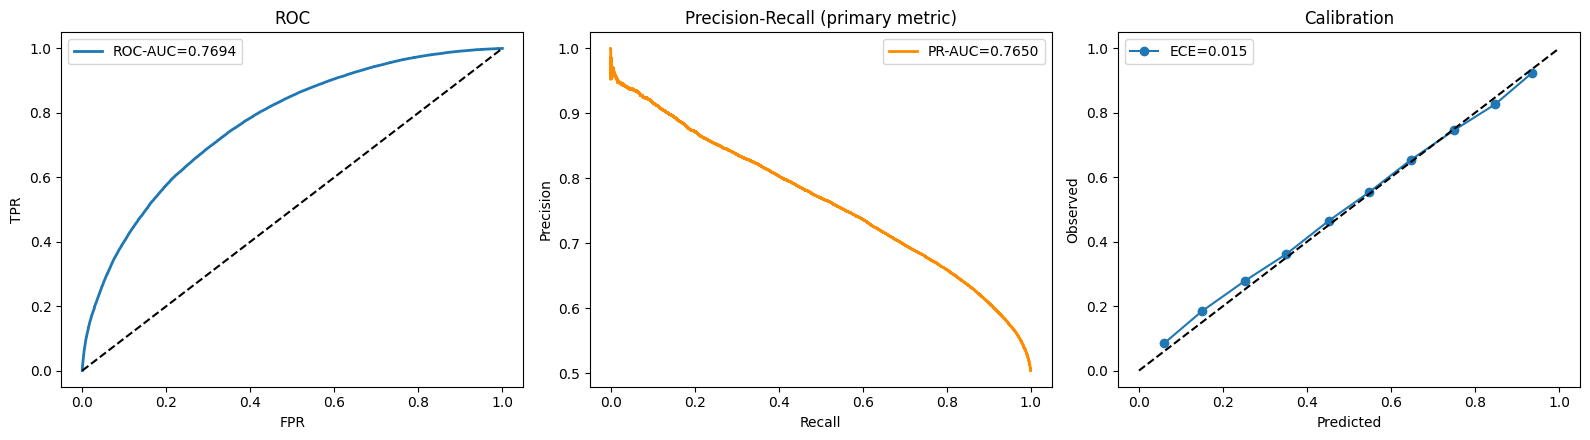

In [19]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, precision_recall_curve

def expected_calibration_error(y, p, bins=10):
    edges = np.linspace(0, 1, bins+1); ece = 0.0
    for i in range(bins):
        m = (p > edges[i]) & (p <= edges[i+1])
        if m.sum() > 0:
            ece += (m.mean()) * abs(y[m].mean() - p[m].mean())
    return ece

ece = expected_calibration_error(yte_d, s_hero)
print(f'LitePhospho ECE: {ece:.4f}  (lower = better calibrated)')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
fpr, tpr, _ = roc_curve(yte_d, s_hero)
ax[0].plot(fpr, tpr, lw=2, label=f"ROC-AUC={results['LitePhospho (ours)']['ROC_AUC']:.4f}")
ax[0].plot([0,1],[0,1],'k--'); ax[0].set_title('ROC'); ax[0].legend(); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
pr, rc, _ = precision_recall_curve(yte_d, s_hero)
ax[1].plot(rc, pr, lw=2, color='darkorange', label=f"PR-AUC={results['LitePhospho (ours)']['PR_AUC']:.4f}")
ax[1].set_title('Precision-Recall (primary metric)'); ax[1].legend(); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
pt, pp = calibration_curve(yte_d, s_hero, n_bins=10)
ax[2].plot(pp, pt, 'o-', label=f'ECE={ece:.3f}'); ax[2].plot([0,1],[0,1],'k--')
ax[2].set_title('Calibration'); ax[2].legend(); ax[2].set_xlabel('Predicted'); ax[2].set_ylabel('Observed')
plt.tight_layout(); plt.savefig(SAVE_DIR / 'curves_v4.png', dpi=150); plt.show()

## Segment 12 — Efficiency / green-computing metrics

Measures CPU latency, model size and a CO2 estimate (Bangladesh grid factor 0.67 kg/kWh),
supplying the numbers your proposal's Green Computing section needs.

In [20]:
import time, copy
cpu_model = copy.deepcopy(hero).cpu().eval()
x1 = torch.zeros(1, WINDOW, dtype=torch.long)
with torch.no_grad():
    for _ in range(10): cpu_model(x1)            # warmup
    t0 = time.time()
    for _ in range(1000): cpu_model(x1)
    lat = (time.time()-t0)/1000*1000
size_mb = sum(p.numel()*4 for p in hero.parameters())/1024/1024
print(f'CPU latency / site : {lat:.3f} ms')
print(f'Model params       : {n_params:,}')
print(f'Model size (fp32)  : {size_mb:.2f} MB')

# TRAIN_HOURS is taken from the actual measured training time (Segment 8).
# T4 board power is ~70 W; GRID = Bangladesh grid factor (kg CO2 / kWh).
TRAIN_HOURS = TRAIN_SECONDS/3600 if 'TRAIN_SECONDS' in globals() else 2.0
GPU_WATTS, GRID = 70, 0.67
kwh = GPU_WATTS/1000 * TRAIN_HOURS
print(f'Measured train time : {TRAIN_HOURS:.2f} h')
print(f'Est. training energy: {kwh:.3f} kWh  ->  {kwh*GRID:.3f} kg CO2')

CPU latency / site : 0.961 ms
Model params       : 436,577
Model size (fp32)  : 1.67 MB
Measured train time : 0.19 h
Est. training energy: 0.013 kWh  ->  0.009 kg CO2


## Segment 13 — Explainability: Integrated Gradients + faithfulness deletion test

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.9 MB/s eta 0:00:00


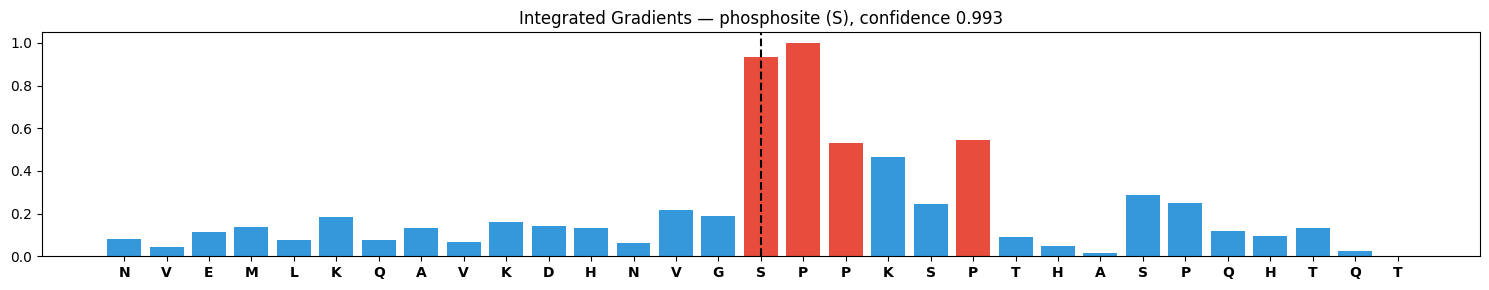

In [21]:
!pip install captum -q
from captum.attr import IntegratedGradients

def captum_fwd(embedded):
    return hero(x=None, embedded=embedded)
ig = IntegratedGradients(captum_fwd)

def ig_scores(input_ids):
    emb = hero.embedding.weight[input_ids].detach().requires_grad_(True)
    hero.eval()
    attr = ig.attribute(emb, torch.zeros_like(emb), n_steps=50)
    return attr.squeeze(0).sum(-1).detach().cpu().numpy()

# Highest-confidence positive in the test set
pos_ids = (test_ds.y == 1).nonzero(as_tuple=True)[0][:300]
best, best_p = None, 0.0
hero.eval()
with torch.no_grad():
    for i in pos_ids:
        p = torch.sigmoid(hero(test_ds.X[i].unsqueeze(0).to(device))).item()
        if p > best_p: best_p, best = p, i
ids = test_ds.X[best].unsqueeze(0).to(device)
scores = ig_scores(ids)
seq = [idx_to_aa[t.item()] for t in test_ds.X[best]]
c = WINDOW//2
norm = (scores - scores.min())/(scores.max()-scores.min()+1e-8)
plt.figure(figsize=(15,3))
plt.bar(range(WINDOW), norm, color=['#e74c3c' if s>0.5 else '#3498db' for s in norm])
plt.axvline(c, color='k', ls='--'); plt.xticks(range(WINDOW), seq, fontweight='bold')
plt.title(f'Integrated Gradients — phosphosite ({seq[c]}), confidence {best_p:.3f}')
plt.tight_layout(); plt.savefig(SAVE_DIR / 'ig_v4.png', dpi=150); plt.show()

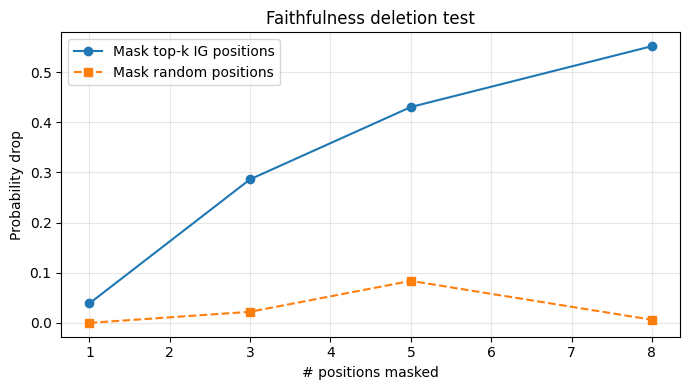

Top-k drops: [0.039 0.286 0.431 0.552] | random drops: [0.    0.022 0.084 0.006]


In [22]:
# Faithfulness deletion test: mask the top-k IG positions; a faithful explanation
# should drop the prediction more than masking random positions does.
def prob_after_mask(ids, mask_pos):
    x = ids.clone()
    for m in mask_pos: x[0, m] = PAD_IDX
    with torch.no_grad():
        return torch.sigmoid(hero(x)).item()

order = np.argsort(-scores)
base  = best_p
topk_drop, rand_drop = [], []
for k in [1, 3, 5, 8]:
    topk_drop.append(base - prob_after_mask(ids, order[:k]))
    rand_drop.append(base - prob_after_mask(ids, rng.choice(WINDOW, k, replace=False)))
plt.figure(figsize=(7,4))
plt.plot([1,3,5,8], topk_drop, 'o-', label='Mask top-k IG positions')
plt.plot([1,3,5,8], rand_drop, 's--', label='Mask random positions')
plt.xlabel('# positions masked'); plt.ylabel('Probability drop')
plt.title('Faithfulness deletion test'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(SAVE_DIR / 'deletion_test_v4.png', dpi=150); plt.show()
print('Top-k drops:', np.round(topk_drop,3), '| random drops:', np.round(rand_drop,3))

## Segment 14 — Motif logo from high-confidence predictions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 73.2 MB/s eta 0:00:00


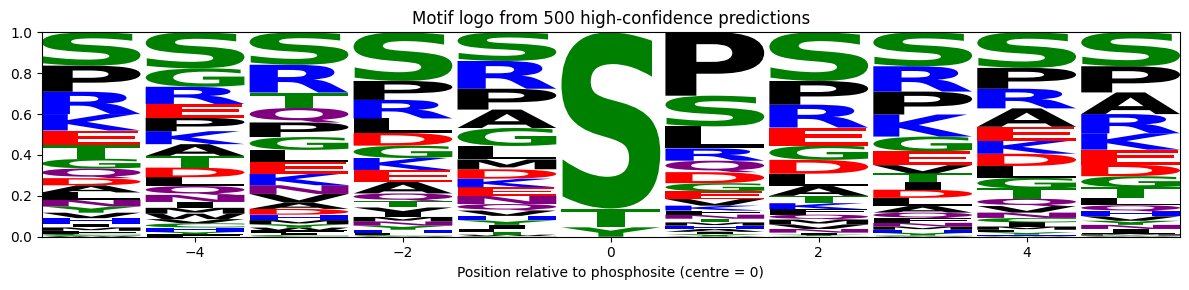

In [23]:
!pip install logomaker -q
import logomaker
hero.eval(); wins = []
with torch.no_grad():
    for i in range(len(test_ds)):
        if test_ds.y[i].item() == 1:
            if torch.sigmoid(hero(test_ds.X[i].unsqueeze(0).to(device))).item() > 0.85:
                wins.append([idx_to_aa[t.item()] for t in test_ds.X[i]])
        if len(wins) >= 500: break
AA = list('ACDEFGHIKLMNPQRSTVWY')
M = pd.DataFrame(0.0, index=range(WINDOW), columns=AA)
for w in wins:
    for pp, aa in enumerate(w):
        if aa in AA: M.loc[pp, aa] += 1
M = M.div(M.sum(1)+1e-8, axis=0)

c = WINDOW//2
sub = M.iloc[c-5:c+6].copy()
sub.index = list(range(-5, 6))                      # <-- CHANGE A: align positions to axis
fig, ax = plt.subplots(figsize=(12, 3))
logomaker.Logo(sub, ax=ax, color_scheme='chemistry')
ax.set_xlabel('Position relative to phosphosite (centre = 0)')   # <-- added
ax.set_title(f'Motif logo from {len(wins)} high-confidence predictions')
# <-- CHANGE B: the old ax.set_xticks(...)/set_xticklabels(...) line is REMOVED
plt.tight_layout(); plt.savefig(SAVE_DIR / 'motif_v4.png', dpi=150); plt.show()

## Segment 15 — ONNX export (CPU deployment)

In [24]:
!pip install onnxscript -q
import os
hero.eval().cpu()
onnx_path = str(SAVE_DIR / 'litephospho_v4.onnx')
torch.onnx.export(hero, torch.zeros(1, WINDOW, dtype=torch.long), onnx_path,
                  input_names=['sequence'], output_names=['logit'],
                  dynamic_axes={'sequence': {0: 'batch'}, 'logit': {0: 'batch'}},
                  opset_version=18)
hero.to(device)
print('ONNX saved:', onnx_path, '|', f'{os.path.getsize(onnx_path)/1024/1024:.2f} MB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 13.5 MB/s eta 0:00:00


/tmp/ipykernel_23/1894523463.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(hero, torch.zeros(1, WINDOW, dtype=torch.long), onnx_path,


[torch.onnx] Obtain model graph for `LitePhospho([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LitePhospho([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX saved: /kaggle/working/litephospho_v4.onnx | 0.03 MB


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


## Segment 16 — External disease validation (PTMD 2.0)

Independent test on **PTMD 2.0** disease-associated phosphosites (your reference [2]).
The cell auto-detects the accession / type / position columns in `Total.txt`, keeps only
phosphorylation on S/T/Y, and splits the sites into:
- **all sites** — every mapped disease phosphosite, and
- **UNSEEN proteins** — sites on proteins the model never trained on.

**Report the UNSEEN-proteins recall** in the paper — that is the genuinely external number
and answers 'can LitePhospho recover disease phosphosites it has never seen?'

In [25]:
# ---- Parse PTMD 2.0 'Total.txt' and run external disease validation ----
# Auto-detects columns so you don't have to hand-edit names.
import re

ptmd = pd.read_csv(PTMD_PATH, sep=None, engine='python')
print('PTMD columns :', list(ptmd.columns))
print(ptmd.head(3).to_string())

# 1) accession column = the one that best matches UniProt accession format
acc_c = pick_acc_column(ptmd)
# 2) type column = first column whose values mention 'phospho'
type_c = next((c for c in ptmd.columns
               if ptmd[c].astype(str).str.contains('phospho', case=False, na=False).any()), None)

def parse_pos(v):
    s = str(v).strip()
    m = re.match(r'^([A-Za-z])?(\d+)', s)
    if m:
        return (m.group(1).upper() if m.group(1) else None), int(m.group(2))
    return None, None

# 3) position column = name hint, else the column whose numbers land on S/T/Y most often
pos_c = next((c for c in ptmd.columns if any(k in c.lower() for k in ['position', 'site', 'pos'])), None)
if pos_c is None:
    best, bh = None, -1
    for c in ptmd.columns:
        if c in (acc_c, type_c):
            continue
        hit = tot = 0
        for _, r in ptmd.head(500).iterrows():
            a = str(r[acc_c]).split('-')[0].strip()
            _, p = parse_pos(r[c])
            if a in seq_dict and p and 0 <= p-1 < len(seq_dict[a]):
                tot += 1
                hit += seq_dict[a][p-1] in 'STY'
        if tot > 20 and hit/tot > bh:
            bh, best = hit/tot, c
    pos_c = best
print(f'\nDetected -> accession: {acc_c} | type: {type_c} | position: {pos_c}')

# Keep only phosphorylation rows
if type_c:
    ptmd = ptmd[ptmd[type_c].astype(str).str.contains('phospho', case=False, na=False)]
print(f'Phosphorylation rows in PTMD: {len(ptmd):,}')

# Proteins the model actually trained on (exclude these for a genuinely external test)
train_proteins = {a for a in pos_proteins if prot2cluster.get(a) in train_cl}

seen_recs, unseen_recs = [], []
for _, r in ptmd.iterrows():
    a = str(r[acc_c]).split('-')[0].strip()
    _, p = parse_pos(r[pos_c])
    if a not in seq_dict or not p:
        continue
    i = p - 1
    if not (0 <= i < len(seq_dict[a])) or seq_dict[a][i] not in 'STY':
        continue
    win = ('X'*HALF + seq_dict[a] + 'X'*HALF)[i:i+WINDOW]
    if len(win) != WINDOW:
        continue
    (seen_recs if a in train_proteins else unseen_recs).append(win)

def recall(wins, thr=0.5, bs=4096):
    """Batched inference — avoids the CUDA OOM from scoring all sites at once."""
    if not wins:
        return None, 0
    hero.eval()
    hits = 0
    with torch.no_grad():
        for k in range(0, len(wins), bs):
            X = torch.stack([encode_window(w) for w in wins[k:k+bs]]).to(device)
            pr = torch.sigmoid(hero(X)).cpu().numpy()
            hits += int((pr >= thr).sum())
    return hits/len(wins), len(wins)

r_all, n_all = recall(seen_recs + unseen_recs)
r_uns, n_uns = recall(unseen_recs)
print(f'\nDisease phosphosites mapped : {n_all:,}')
if r_all is not None:
    print(f'Recall@0.5 (all sites)      : {r_all:.3f}')
if r_uns is not None:
    print(f'Recall@0.5 (UNSEEN proteins): {r_uns:.3f}  (n={n_uns:,})  <- report THIS as external validation')

PTMD columns : ['UniProt', 'Position', 'Type', 'State', 'Disease', 'MutationSite', 'Source', 'Residue', 'Is_experimental_verification', 'Enzyme', 'Gene name', 'PMID', 'Sentence', 'CellType', 'PDAs_id']
      UniProt  Position             Type State                                Disease MutationSite              Source Residue  Is_experimental_verification Enzyme Gene name PMID Sentence CellType  PDAs_id
0  A0A024RCH0     125.0  Phosphorylation     N               Adrenocortical carcinoma    ['D120N']  ['ActiveDriverDB']       S                             0    NaN       NaN  NaN      NaN      NaN  PDA6740
1  A0A024RCH0     125.0  Phosphorylation     N                   Colon adenocarcinoma    ['E127D']  ['ActiveDriverDB']       S                             0    NaN       NaN  NaN      NaN      NaN  PDA6741
2  A0A024RCH0     125.0  Phosphorylation     N  Head and neck squamous cell carcinoma    ['D120N']  ['ActiveDriverDB']       S                             0    NaN       NaN  NaN  

## Segment 17 — Figures for thesis & paper

Run after every cell above. Saves all figures as 200-dpi PNGs in SAVE_DIR.

### 17a — Dataset & performance figures

In [26]:
# ===== 17a — Dataset & performance figures =====
import numpy as np, matplotlib.pyplot as plt, torch, itertools
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             precision_score, recall_score, f1_score)
FIG = SAVE_DIR
y_true = np.asarray(yte)

def _mm(s):
    s = np.asarray(s, float); return (s - s.min()) / (s.max() - s.min() + 1e-9)

# Test scores for every model (all still in memory)
model_scores = {
    'LogReg'      : lr.predict_proba(Xte)[:, 1],
    'SVM'         : _mm(svm.decision_function(Xte)),
    'RandomForest': rf.predict_proba(Xte)[:, 1],
    'XGBoost'     : xgbc.predict_proba(Xte)[:, 1],
    'PlainCNN'    : deep_scores(plain, test_loader)[1],
    'LitePhospho' : deep_scores(hero, test_loader)[1],
}
with torch.no_grad():
    model_scores['LitePhospho-ESM2'] = torch.sigmoid(
        esm_head(torch.from_numpy(Xte_e.astype('float32')).to(device))).cpu().numpy()
s_main = model_scores['LitePhospho']

# 1) Dataset distribution
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(['Positive', 'Negative'], [len(pos_records), len(neg_bal)], color=['#e74c3c', '#3498db'])
ax[0].set_title('Class distribution (balanced)'); ax[0].set_ylabel('windows')
ax[1].bar(['Train', 'Val', 'Test'], [len(train_recs), len(val_recs), len(test_recs)],
          color=['#2ecc71', '#f39c12', '#9b59b6'])
ax[1].set_title('Homology-aware split (30% identity)'); ax[1].set_ylabel('windows')
for a in ax:
    for p in a.patches:
        a.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                   ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.savefig(FIG/'fig_dataset.png', dpi=200, bbox_inches='tight'); plt.close()

# 2) Training curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(tr_hist)+1), tr_hist, label='Train loss', color='#2ecc71', lw=2)
plt.plot(range(1, len(va_hist)+1), va_hist, label='Val loss', color='#e74c3c', lw=2)
be = int(np.argmin(va_hist))+1
plt.axvline(be, ls='--', color='gray', label=f'best epoch {be}')
plt.xlabel('Epoch'); plt.ylabel('BCE loss'); plt.title('LitePhospho training curves')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig_training_curves.png', dpi=200, bbox_inches='tight'); plt.close()

# 3) ROC overlay (all models)
plt.figure(figsize=(7, 6))
for name, s in model_scores.items():
    fpr, tpr, _ = roc_curve(y_true, s)
    plt.plot(fpr, tpr, lw=2.4 if name == 'LitePhospho' else 1.2,
             label=f'{name} ({roc_auc_score(y_true, s):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC — all models (test)'); plt.legend(fontsize=8, loc='lower right'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig_roc_all.png', dpi=200, bbox_inches='tight'); plt.close()

# 4) PR overlay (all models)
plt.figure(figsize=(7, 6))
for name, s in model_scores.items():
    pr, rc, _ = precision_recall_curve(y_true, s)
    plt.plot(rc, pr, lw=2.4 if name == 'LitePhospho' else 1.2,
             label=f'{name} ({average_precision_score(y_true, s):.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall — all models (test)')
plt.legend(fontsize=8, loc='lower left'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig_pr_all.png', dpi=200, bbox_inches='tight'); plt.close()

# 5) Confusion matrix (LitePhospho)
pred = (s_main >= 0.5).astype(int); cm = confusion_matrix(y_true, pred)
plt.figure(figsize=(5.5, 5)); plt.imshow(cm, cmap='Blues')
for i, j in itertools.product(range(2), range(2)):
    plt.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=13, fontweight='bold',
             color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.xticks([0, 1], ['Non-phospho', 'Phospho']); plt.yticks([0, 1], ['Non-phospho', 'Phospho'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion matrix — LitePhospho (test)')
plt.colorbar(); plt.tight_layout(); plt.savefig(FIG/'fig_confusion.png', dpi=200, bbox_inches='tight'); plt.close()

# 6) Per-class metrics
m = ['Precision', 'Recall', 'F1']
neg = [precision_score(y_true, pred, pos_label=0), recall_score(y_true, pred, pos_label=0), f1_score(y_true, pred, pos_label=0)]
pos = [precision_score(y_true, pred), recall_score(y_true, pred), f1_score(y_true, pred)]
x = np.arange(3); w = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x-w/2, neg, w, label='Non-phospho', color='#3498db')
plt.bar(x+w/2, pos, w, label='Phospho', color='#e74c3c')
plt.xticks(x, m); plt.ylim(0.5, 0.85); plt.ylabel('Score')
plt.title('Per-class metrics — LitePhospho'); plt.legend(); plt.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig_perclass.png', dpi=200, bbox_inches='tight'); plt.close()

# 7) Threshold analysis
ths = np.linspace(0.05, 0.95, 19); P, R, Fa = [], [], []
for t in ths:
    pp = (s_main >= t).astype(int)
    P.append(precision_score(y_true, pp, zero_division=0))
    R.append(recall_score(y_true, pp, zero_division=0))
    Fa.append(f1_score(y_true, pp, zero_division=0))
plt.figure(figsize=(8, 5))
plt.plot(ths, P, label='Precision'); plt.plot(ths, R, label='Recall'); plt.plot(ths, Fa, label='F1')
bi = int(np.argmax(Fa)); plt.axvline(ths[bi], ls='--', color='gray', label=f'best F1 @ {ths[bi]:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.title('Threshold analysis — LitePhospho')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig_threshold.png', dpi=200, bbox_inches='tight'); plt.close()

# 8) Score distribution
plt.figure(figsize=(8, 5))
plt.hist(s_main[y_true == 1], bins=50, alpha=.6, label='Phospho', color='#e74c3c', density=True)
plt.hist(s_main[y_true == 0], bins=50, alpha=.6, label='Non-phospho', color='#3498db', density=True)
plt.axvline(0.5, ls='--', color='k'); plt.xlabel('Predicted probability'); plt.ylabel('Density')
plt.title('Predicted score distribution — LitePhospho'); plt.legend()
plt.tight_layout(); plt.savefig(FIG/'fig_scoredist.png', dpi=200, bbox_inches='tight'); plt.close()

# 9) Comparison grouped bar
order = sorted(results, key=lambda k: results[k]['PR_AUC'])
met = ['ROC_AUC', 'PR_AUC', 'F1']; xx = np.arange(len(order)); w = 0.25
plt.figure(figsize=(11, 5))
for j, mm in enumerate(met):
    plt.bar(xx+(j-1)*w, [results[k][mm] for k in order], w, label=mm)
plt.xticks(xx, order, rotation=30, ha='right'); plt.ylim(0.6, 0.85); plt.ylabel('Score')
plt.title('Model comparison (leakage-free 30% split, same test set)')
plt.legend(); plt.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig_comparison.png', dpi=200, bbox_inches='tight'); plt.close()

print('Saved 9 figures: dataset, training_curves, roc_all, pr_all, confusion, perclass, threshold, scoredist, comparison')


Saved 9 figures: dataset, training_curves, roc_all, pr_all, confusion, perclass, threshold, scoredist, comparison


### 17b — Efficiency, explainability & disease figures

In [27]:
# ===== 17b — Efficiency, explainability & disease figures =====
import numpy as np, matplotlib.pyplot as plt, torch
from captum.attr import IntegratedGradients
FIG = SAVE_DIR

# 10) Accuracy vs params (efficiency tradeoff)
pts = {
    'PlainCNN'        : (sum(p.numel() for p in plain.parameters()), results['PlainCNN']['PR_AUC']),
    'LitePhospho'     : (sum(p.numel() for p in hero.parameters()),  results['LitePhospho (ours)']['PR_AUC']),
    'LitePhospho-ESM2': (8_000_000 + sum(p.numel() for p in esm_head.parameters()), results['LitePhospho-ESM2 (ours)']['PR_AUC']),
}
plt.figure(figsize=(8, 5))
for name, (pa, au) in pts.items():
    plt.scatter(pa, au, s=140)
    plt.annotate(name, (pa, au), xytext=(6, 6), textcoords='offset points', fontsize=9)
plt.xscale('log'); plt.xlabel('Parameters (log scale)'); plt.ylabel('PR-AUC')
plt.title('Accuracy vs model size (lightweight wins)'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig_tradeoff.png', dpi=200, bbox_inches='tight'); plt.close()

# 11) Green computing — training CO2
heavy_kwh = 250/1000 * 360            # proposal's "typical heavy workflow"
lite_kwh  = GPU_WATTS/1000 * TRAIN_HOURS
plt.figure(figsize=(6.5, 5))
b = plt.bar(['Typical heavy\nworkflow', 'LitePhospho'],
            [heavy_kwh*GRID, lite_kwh*GRID], color=['#7f8c8d', '#2ecc71'])
for p in b.patches:
    plt.annotate(f'{p.get_height():.2f} kg', (p.get_x()+p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontweight='bold')
plt.ylabel('Training CO2 (kg, log scale)'); plt.yscale('log')
plt.title('Training carbon footprint')
plt.tight_layout(); plt.savefig(FIG/'fig_green_co2.png', dpi=200, bbox_inches='tight'); plt.close()

# ---- Integrated Gradients helpers (reused for figures 12 & 13) ----
def _fwd(e):
    return hero(x=None, embedded=e)
_ig = IntegratedGradients(_fwd)
def _scores(ids):
    e = hero.embedding.weight[ids].detach().requires_grad_(True); hero.eval()
    return _ig.attribute(e, torch.zeros_like(e), n_steps=32).squeeze(0).sum(-1).detach().cpu().numpy()
def _mask_prob(ids, positions):
    x = ids.clone()
    for m in positions:
        x[0, m] = PAD_IDX
    with torch.no_grad():
        return torch.sigmoid(hero(x)).item()

# 12) Averaged faithfulness deletion test (over up to 100 positive sites)
posidx = (test_ds.y == 1).nonzero(as_tuple=True)[0][:100]
ks = [1, 2, 3, 5, 8]; topk = np.zeros(len(ks)); rnd = np.zeros(len(ks)); cnt = 0
for i in posidx:
    ids = test_ds.X[i].unsqueeze(0).to(device)
    with torch.no_grad():
        base = torch.sigmoid(hero(ids)).item()
    sc = _scores(ids); order = np.argsort(-sc)
    for j, k in enumerate(ks):
        topk[j] += base - _mask_prob(ids, order[:k])
        rnd[j]  += base - _mask_prob(ids, np.random.choice(WINDOW, k, replace=False))
    cnt += 1
topk /= cnt; rnd /= cnt
plt.figure(figsize=(7, 5))
plt.plot(ks, topk, 'o-', label='Mask top-k IG positions')
plt.plot(ks, rnd, 's--', label='Mask random positions')
plt.xlabel('# positions masked'); plt.ylabel('Mean probability drop')
plt.title(f'Faithfulness deletion test (avg over {cnt} sites)')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig_deletion_avg.png', dpi=200, bbox_inches='tight'); plt.close()

# 13) IG attribution — confident positive + confident negative
def _plot_ig(ax, ids, title):
    sc = _scores(ids); seq = [idx_to_aa[t.item()] for t in ids.squeeze()]
    n = (sc - sc.min()) / (sc.max() - sc.min() + 1e-9); c = WINDOW//2
    ax.bar(range(WINDOW), n, color=['#e74c3c' if v > 0.5 else '#3498db' for v in n])
    ax.axvline(c, color='k', ls='--'); ax.set_xticks(range(WINDOW))
    ax.set_xticklabels(seq, fontsize=7, fontweight='bold'); ax.set_title(title)
negidx = (test_ds.y == 0).nonzero(as_tuple=True)[0]
bestp, bp = 0.0, posidx[0]; worstn, bn = 1.0, negidx[0]
with torch.no_grad():
    for i in posidx:
        p = torch.sigmoid(hero(test_ds.X[i].unsqueeze(0).to(device))).item()
        if p > bestp: bestp, bp = p, i
    for i in negidx[:200]:
        p = torch.sigmoid(hero(test_ds.X[i].unsqueeze(0).to(device))).item()
        if p < worstn: worstn, bn = p, i
fig, ax = plt.subplots(2, 1, figsize=(15, 6))
_plot_ig(ax[0], test_ds.X[bp].unsqueeze(0).to(device), f'Phosphosite (confidence {bestp:.2f})')
_plot_ig(ax[1], test_ds.X[bn].unsqueeze(0).to(device), f'Non-phosphosite (confidence {worstn:.2f})')
plt.tight_layout(); plt.savefig(FIG/'fig_ig_examples.png', dpi=200, bbox_inches='tight'); plt.close()

# 14) External disease validation (PTMD 2.0)
plt.figure(figsize=(6, 5))
b = plt.bar(['All disease\nsites', 'UNSEEN\nproteins'], [r_all, r_uns], color=['#95a5a6', '#e74c3c'])
for p in b.patches:
    plt.annotate(f'{p.get_height():.3f}', (p.get_x()+p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1); plt.ylabel('Recall @ 0.5')
plt.title(f'External disease validation (PTMD 2.0)\nUNSEEN proteins n={n_uns:,}')
plt.tight_layout(); plt.savefig(FIG/'fig_ptmd.png', dpi=200, bbox_inches='tight'); plt.close()

print('Saved 5 figures: tradeoff, green_co2, deletion_avg, ig_examples, ptmd')


Saved 5 figures: tradeoff, green_co2, deletion_avg, ig_examples, ptmd


### 17c — Leakage ablation (centerpiece figure)

Retrains the same model under 3 split protocols (~30 min extra).

In [28]:
# ===== 17c — Leakage ablation (centerpiece): same model, three split protocols =====
# Retrains the SAME LitePhospho under random / protein-level / 30%-identity splits
# to show that reported performance inflates as leakage increases.
import numpy as np, matplotlib.pyplot as plt, torch, copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
FIG = SAVE_DIR

def quick_train_eval(tr, va, te, epochs=40):
    trl = DataLoader(PhosphoDataset(tr), 512, shuffle=True, num_workers=2, pin_memory=True)
    vds = PhosphoDataset(va); vall = DataLoader(vds, 1024)
    tel = DataLoader(PhosphoDataset(te), 1024)
    m = LitePhospho(NAA).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=1e-4)
    crit = nn.BCEWithLogitsLoss(); best, wait, bsd = 1e9, 0, None
    for ep in range(1, epochs+1):
        m.train()
        for bx, by in trl:
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad(); crit(m(bx), by).backward(); opt.step()
        m.eval(); tot = 0.0
        with torch.no_grad():
            for bx, by in vall:
                bx, by = bx.to(device), by.to(device)
                tot += crit(m(bx), by).item()*bx.size(0)
        vl = tot/len(vds)
        if vl < best: best, wait, bsd = vl, 0, copy.deepcopy(m.state_dict())
        else:
            wait += 1
            if wait >= 8: break
    m.load_state_dict(bsd); m.eval(); ys, ss = [], []
    with torch.no_grad():
        for bx, by in tel:
            ss.append(torch.sigmoid(m(bx.to(device))).cpu()); ys.append(by)
    y = torch.cat(ys).numpy(); s = torch.cat(ss).numpy()
    return roc_auc_score(y, s), average_precision_score(y, s)

lab = [r[3] for r in all_records]
# (a) RANDOM window split (most leaky)
a_tr, a_tmp = train_test_split(all_records, test_size=0.3, random_state=1, stratify=lab)
a_va, a_te = train_test_split(a_tmp, test_size=0.5, random_state=1, stratify=[r[3] for r in a_tmp])
print('Training under RANDOM split...'); roc_a, pr_a = quick_train_eval(a_tr, a_va, a_te)

# (b) PROTEIN-level split (partial leak via homologs)
prots = sorted(pos_proteins)
p_tr, p_tmp = train_test_split(prots, test_size=0.3, random_state=1)
p_va, p_te = train_test_split(p_tmp, test_size=0.5, random_state=1)
p_tr, p_va, p_te = set(p_tr), set(p_va), set(p_te)
b_tr = [r for r in all_records if r[0] in p_tr]
b_va = [r for r in all_records if r[0] in p_va]
b_te = [r for r in all_records if r[0] in p_te]
print('Training under PROTEIN-level split...'); roc_b, pr_b = quick_train_eval(b_tr, b_va, b_te)

# (c) 30% identity cluster split (leakage-free) — already trained as the main hero
roc_c = results['LitePhospho (ours)']['ROC_AUC']
pr_c  = results['LitePhospho (ours)']['PR_AUC']

names = ['Random\n(window)', 'Protein-level', 'Homology 30%\n(leakage-free)']
rocs = [roc_a, roc_b, roc_c]; prs = [pr_a, pr_b, pr_c]
x = np.arange(3); w = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x-w/2, rocs, w, label='ROC-AUC', color='#3498db')
plt.bar(x+w/2, prs,  w, label='PR-AUC',  color='#e74c3c')
for i in range(3):
    plt.text(x[i]-w/2, rocs[i], f'{rocs[i]:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(x[i]+w/2, prs[i],  f'{prs[i]:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(x, names); plt.ylim(0.6, 1.0); plt.ylabel('Score')
plt.title('Same model, three evaluation protocols\n(performance inflates as leakage increases)')
plt.legend(); plt.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig_leakage_ablation.png', dpi=200, bbox_inches='tight'); plt.close()
print(f'Leakage ablation ROC -> random {roc_a:.3f} | protein {roc_b:.3f} | homology {roc_c:.3f}')
print('Saved: fig_leakage_ablation')


Training under RANDOM split...
Training under PROTEIN-level split...
Leakage ablation ROC -> random 0.797 | protein 0.784 | homology 0.769
Saved: fig_leakage_ablation


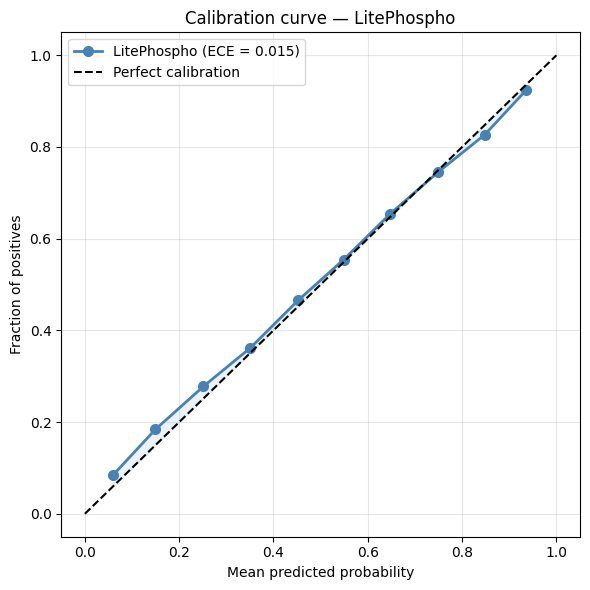

Saved fig_calibration.png | ECE = 0.0147


In [29]:
# ===== Standalone calibration figure -> fig_calibration.png (Fig 4.10) =====
from sklearn.calibration import calibration_curve
import numpy as np, matplotlib.pyplot as plt, torch

hero.eval(); _ys, _ss = [], []
with torch.no_grad():
    for bx, by in test_loader:
        _ss.append(torch.sigmoid(hero(bx.to(device))).cpu()); _ys.append(by)
y_true = torch.cat(_ys).numpy(); p = torch.cat(_ss).numpy()

def _ece(y, prob, bins=10):
    edges = np.linspace(0, 1, bins+1); e = 0.0
    for i in range(bins):
        m = (prob > edges[i]) & (prob <= edges[i+1])
        if m.sum() > 0:
            e += m.mean() * abs(y[m].mean() - prob[m].mean())
    return e
ece = _ece(y_true, p)

pt, pp = calibration_curve(y_true, p, n_bins=10)
plt.figure(figsize=(6, 6))
plt.plot(pp, pt, 'o-', color='steelblue', lw=2, markersize=7, label=f'LitePhospho (ECE = {ece:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
plt.fill_between(pp, pt, pp, alpha=0.1, color='steelblue')
plt.xlabel('Mean predicted probability'); plt.ylabel('Fraction of positives')
plt.title('Calibration curve — LitePhospho'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(SAVE_DIR / 'fig_calibration.png', dpi=200, bbox_inches='tight'); plt.show()
print('Saved fig_calibration.png | ECE =', round(ece, 4))

In [30]:
# ===== Q1-Exp A: realistic-prevalence evaluation (reuses trained `hero`) =====
import numpy as np, torch
from sklearn.metrics import roc_auc_score, average_precision_score

def score_windows(win_list, bs=4096):
    hero.eval(); out = []
    with torch.no_grad():
        for k in range(0, len(win_list), bs):
            X = torch.stack([encode_window(w) for w in win_list[k:k+bs]]).to(device)
            out.append(torch.sigmoid(hero(X)).cpu().numpy())
    return np.concatenate(out) if out else np.array([])

# Positives on test proteins + ALL non-site S/T/Y negatives on test proteins
# (not the 1:1 subsample) -> the natural ratio on these proteins.
test_pos      = [r for r in test_recs   if r[3] == 1]
test_neg_full = [r for r in neg_records if split_of(r[0]) == 'test']
recs = test_pos + test_neg_full
y = np.array([r[3] for r in recs]); s = score_windows([r[2] for r in recs])
prev = y.mean()
print(f"Realistic test set: {len(recs):,} windows | pos {len(test_pos):,} / neg {len(test_neg_full):,}")
print(f"Prevalence (pos frac)     : {prev:.3f}   (was forced to 0.50 in the 1:1 eval)")
print(f"ROC-AUC                   : {roc_auc_score(y, s):.3f}")
print(f"PR-AUC                    : {average_precision_score(y, s):.3f}")
print(f"PR-AUC random baseline    : {prev:.3f}   <- compare PR-AUC against THIS, not 0.5")

Realistic test set: 275,929 windows | pos 87,018 / neg 188,911
Prevalence (pos frac)     : 0.315   (was forced to 0.50 in the 1:1 eval)
ROC-AUC                   : 0.769
PR-AUC                    : 0.612
PR-AUC random baseline    : 0.315   <- compare PR-AUC against THIS, not 0.5


In [31]:
# ===== Q1-Exp B: per-residue breakdown (run after Cell A; reuses score_windows) =====
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
y_all  = np.array([r[3] for r in test_recs])
s_all  = score_windows([r[2] for r in test_recs])          # balanced test, aligned to test_recs
center = np.array([r[2][HALF] for r in test_recs])         # HALF=15 -> phosphoacceptor
print(f"{'res':>4} {'n':>9} {'n_pos':>8} {'ROC-AUC':>8} {'PR-AUC':>8} {'F1@0.5':>7}")
for aa in ['S','T','Y']:
    m = center == aa
    if m.sum()==0 or len(set(y_all[m]))<2: continue
    y, s = y_all[m], s_all[m]
    print(f"{aa:>4} {m.sum():>9,} {int(y.sum()):>8,} "
          f"{roc_auc_score(y,s):>8.3f} {average_precision_score(y,s):>8.3f} "
          f"{f1_score(y,(s>=0.5).astype(int)):>7.3f}")

 res         n    n_pos  ROC-AUC   PR-AUC  F1@0.5
   S    92,578   51,271    0.779    0.804   0.744
   T    53,439   23,861    0.756    0.708   0.637
   Y    26,597   11,886    0.728    0.666   0.600


In [32]:
# ===== OPTIONAL - HEAVIEST CELL (35M ESM2 ceiling). Safe to SKIP; FREEZE works without it. =====
# ===== Q1-Batch 2: HONEST ESM2 baseline =====
# Fixes the weak 8M/center-residue baseline: larger ESM2 + pools the per-residue
# embeddings over the SAME 31-window the CNN sees (mean-pool + center, concatenated).
!pip install fair-esm -q
import esm, numpy as np, torch, copy
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

ESM_NAME, ESM_LAYER = 'esm2_t12_35M_UR50D', 12   # stronger option: 'esm2_t30_150M_UR50D', layer 30
esm_model, alphabet = getattr(esm.pretrained, ESM_NAME)()
batch_converter = alphabet.get_batch_converter()
esm_model = esm_model.eval().to(device)
ESM_DIM, CTX = esm_model.embed_dim, 64
print(f'{ESM_NAME}: dim={ESM_DIM}, layer={ESM_LAYER}')

def esm_pooled_features(recs, bs=32):
    feats = np.zeros((len(recs), 2*ESM_DIM), dtype=np.float16); buf, meta = [], []
    def flush():
        if not buf: return
        _,_,toks = batch_converter(buf); toks = toks.to(device)
        with torch.no_grad():
            rep = esm_model(toks, repr_layers=[ESM_LAYER])['representations'][ESM_LAYER]
        for k,(gi,c,lo_w,hi_w) in enumerate(meta):
            win = rep[k, lo_w+1:hi_w+1].float(); center = rep[k, c+1].float()
            feats[gi] = torch.cat([win.mean(0), center]).cpu().numpy().astype(np.float16)
        buf.clear(); meta.clear()
    for gi, r in enumerate(recs):
        seq = seq_dict[r[0]]; pos = r[1]
        lo = max(0,pos-CTX); hi = min(len(seq),pos+CTX+1); c = pos-lo
        lo_w, hi_w = max(0,c-HALF), min(hi-lo, c+HALF+1)
        buf.append((str(gi), seq[lo:hi])); meta.append((gi,c,lo_w,hi_w))
        if len(buf)>=bs: flush()
    flush(); return feats

print('Extracting fair ESM2 features (one-time, slower than the 8M run)...')
Xtr_e2=esm_pooled_features(train_recs); ytr_e2=np.array([r[3] for r in train_recs],np.float32)
Xva_e2=esm_pooled_features(val_recs);   yva_e2=np.array([r[3] for r in val_recs],  np.float32)
Xte_e2=esm_pooled_features(test_recs);  yte_e2=np.array([r[3] for r in test_recs], np.float32)
del esm_model; torch.cuda.empty_cache(); print('Fair ESM2 features:', Xtr_e2.shape)

class ESMHead2(nn.Module):
    def __init__(self,d,dropout=0.3):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,256),nn.BatchNorm1d(256),nn.ReLU(),nn.Dropout(dropout),
                               nn.Linear(256,64),nn.BatchNorm1d(64),nn.ReLU(),nn.Dropout(dropout),
                               nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(1)

def train_esm_head(Xtr,ytr,Xva,yva,seed=42,epochs=100,patience=10):
    torch.manual_seed(seed)
    trl=DataLoader(TensorDataset(torch.from_numpy(Xtr.astype(np.float32)),torch.from_numpy(ytr)),1024,shuffle=True)
    val=DataLoader(TensorDataset(torch.from_numpy(Xva.astype(np.float32)),torch.from_numpy(yva)),2048)
    head=ESMHead2(Xtr.shape[1]).to(device); opt=torch.optim.AdamW(head.parameters(),lr=1e-3,weight_decay=1e-4)
    crit=nn.BCEWithLogitsLoss(); best,wait,sd=1e9,0,None
    for ep in range(1,epochs+1):
        head.train()
        for bx,by in trl:
            bx,by=bx.to(device),by.to(device); opt.zero_grad(); crit(head(bx),by).backward(); opt.step()
        head.eval(); tot=0.0
        with torch.no_grad():
            for bx,by in val: bx,by=bx.to(device),by.to(device); tot+=crit(head(bx),by).item()*bx.size(0)
        vl=tot/len(val.dataset)
        if vl<best: best,wait,sd=vl,0,copy.deepcopy(head.state_dict())
        else:
            wait+=1
            if wait>=patience: break
    head.load_state_dict(sd); return head

esm_head2=train_esm_head(Xtr_e2,ytr_e2,Xva_e2,yva_e2); esm_head2.eval()
with torch.no_grad():
    s_esm2=torch.sigmoid(esm_head2(torch.from_numpy(Xte_e2.astype(np.float32)).to(device))).cpu().numpy()
record('LitePhospho-ESM2-fair (ours)', yte_e2, s_esm2, (s_esm2>=0.5).astype(int))
model_scores['LitePhospho-ESM2-fair']=s_esm2

# --- the decisive test: does a FAIR ESM2 now beat the from-scratch CNN? ---
yb=np.asarray(y_true); a=np.asarray(model_scores['LitePhospho']); rng=np.random.default_rng(0); n=len(yb)
d=np.array([average_precision_score(yb[ix],a[ix])-average_precision_score(yb[ix],s_esm2[ix])
            for ix in (rng.integers(0,n,n) for _ in range(1000))])
print(f'ΔPR-AUC LitePhospho - ESM2-fair: {d.mean():.3f} [{np.percentile(d,2.5):.3f}, {np.percentile(d,97.5):.3f}], p(CNN not better)={np.mean(d<=0):.3f}')

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t12_35M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t12_35M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t12_35M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t12_35M_UR50D-contact-regression.pt
esm2_t12_35M_UR50D: dim=480, layer=12
Extracting fair ESM2 features (one-time, slower than the 8M run)...
Fair ESM2 features: (807583, 960)
LitePhospho-ESM2-fair (ours) ROC-AUC=0.7750  PR-AUC=0.7790  F1=0.7017
ΔPR-AUC LitePhospho - ESM2-fair: -0.014 [-0.016, -0.012], p(CNN not better)=1.000


In [33]:
# ===== Q1-Batch 3: multi-seed robustness for LitePhospho & PlainCNN =====
import numpy as np, torch, copy
from sklearn.metrics import roc_auc_score, average_precision_score
SEEDS = [0,1,2,3,4]

def train_eval_seed(ModelClass, seed, epochs=150, lr=3e-4, wd=1e-4, patience=20):
    torch.manual_seed(seed); np.random.seed(seed)
    g=torch.Generator().manual_seed(seed)
    trl=DataLoader(train_ds,batch_size=BATCH,shuffle=True,num_workers=2,pin_memory=True,generator=g)
    m=ModelClass(NAA).to(device); crit=nn.BCEWithLogitsLoss()
    opt=torch.optim.AdamW(m.parameters(),lr=lr,weight_decay=wd)
    sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',patience=6,factor=0.5,min_lr=1e-6)
    best,wait,sd=1e9,0,None
    for ep in range(1,epochs+1):
        m.train()
        for bx,by in trl:
            bx,by=bx.to(device),by.to(device); opt.zero_grad()
            loss=crit(m(bx),by); loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
        m.eval(); tot=0.0
        with torch.no_grad():
            for bx,by in val_loader: bx,by=bx.to(device),by.to(device); tot+=crit(m(bx),by).item()*bx.size(0)
        vl=tot/len(val_ds); sched.step(vl)
        if vl<best: best,wait,sd=vl,0,copy.deepcopy(m.state_dict())
        else:
            wait+=1
            if wait>=patience: break
    m.load_state_dict(sd); m.eval(); ys,ss=[],[]
    with torch.no_grad():
        for bx,by in test_loader: ss.append(torch.sigmoid(m(bx.to(device))).cpu()); ys.append(by)
    y=torch.cat(ys).numpy(); s=torch.cat(ss).numpy()
    return roc_auc_score(y,s), average_precision_score(y,s)

for name, Cls in [('LitePhospho', LitePhospho), ('PlainCNN', PlainCNN)]:
    rocs,prs=[],[]
    for sd_ in SEEDS:
        roc,pr=train_eval_seed(Cls,sd_); rocs.append(roc); prs.append(pr)
        print(f'  {name} seed{sd_}: ROC {roc:.4f}  PR {pr:.4f}')
    print(f'{name}: ROC {np.mean(rocs):.3f} ± {np.std(rocs):.3f} | PR {np.mean(prs):.3f} ± {np.std(prs):.3f}  (n={len(SEEDS)})\n')

  LitePhospho seed0: ROC 0.7692  PR 0.7639
  LitePhospho seed1: ROC 0.7685  PR 0.7637
  LitePhospho seed2: ROC 0.7689  PR 0.7640
  LitePhospho seed3: ROC 0.7692  PR 0.7650
  LitePhospho seed4: ROC 0.7682  PR 0.7643
LitePhospho: ROC 0.769 ± 0.000 | PR 0.764 ± 0.000  (n=5)

  PlainCNN seed0: ROC 0.7389  PR 0.7288
  PlainCNN seed1: ROC 0.7404  PR 0.7298
  PlainCNN seed2: ROC 0.7387  PR 0.7292
  PlainCNN seed3: ROC 0.7396  PR 0.7291
  PlainCNN seed4: ROC 0.7393  PR 0.7297
PlainCNN: ROC 0.739 ± 0.001 | PR 0.729 ± 0.000  (n=5)



In [34]:
import gc, torch
for name, Cls in [('DeepPhos', DeepPhosNet), ('MusiteDeep', MusiteDeepNet)]:
    torch.manual_seed(42)
    roc, pr, s, y = train_eval_split(Cls, train_recs, val_recs, test_recs)
    record(f'{name} (reimpl)', y, s, (s>=0.5).astype(int))
    model_scores[f'{name}(reimpl)'] = s
# save_scores()                         # save after EACH model
    print(f'{name}(reimpl): ROC {roc:.4f}  PR {pr:.4f}  | saved')
    gc.collect(); torch.cuda.empty_cache()
print('Step 4 done. Table:', list(model_scores.keys()))

DeepPhos (reimpl)    ROC-AUC=0.7635  PR-AUC=0.7583  F1=0.6955
DeepPhos(reimpl): ROC 0.7635  PR 0.7583  | saved
MusiteDeep (reimpl)  ROC-AUC=0.7612  PR-AUC=0.7547  F1=0.6994
MusiteDeep(reimpl): ROC 0.7612  PR 0.7547  | saved
Step 4 done. Table: ['LogReg', 'SVM', 'RandomForest', 'XGBoost', 'PlainCNN', 'LitePhospho', 'LitePhospho-ESM2', 'LitePhospho-ESM2-fair', 'DeepPhos(reimpl)', 'MusiteDeep(reimpl)']


In [35]:
# ===== Cell C (canonical — keep ONLY this one) =====
# Bootstrap 95% CIs + paired ΔPR-AUC tests. NaN-robust: models with partial
# coverage (e.g. external tools) are handled correctly.
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
y_all = np.asarray(y_true, dtype=float)
B = 1000

def boot_ci(y, s, metric, seed=0):
    r = np.random.default_rng(seed); n = len(y)
    v = np.array([metric(y[ix], s[ix]) for ix in (r.integers(0, n, n) for _ in range(B))])
    return v.mean(), np.percentile(v, 2.5), np.percentile(v, 97.5)

# --- marginal CIs: each model on the sites it actually scored ---
rows = []
for name, sc in model_scores.items():
    sc = np.asarray(sc, dtype=float); m = ~np.isnan(sc) & ~np.isnan(y_all)
    if len(np.unique(y_all[m])) < 2:
        continue
    pm, plo, phi = boot_ci(y_all[m], sc[m], average_precision_score)
    rm, rlo, rhi = boot_ci(y_all[m], sc[m], roc_auc_score)
    rows.append((name, pm, plo, phi, rm, rlo, rhi, int(m.sum())))

print(f"Bootstrap 95% CI (B={B}), ordered by PR-AUC:")
for name, pm, plo, phi, rm, rlo, rhi, cov in sorted(rows, key=lambda t: t[1]):
    tag = '' if cov == len(y_all) else f'  (n={cov:,})'
    print(f"  {name:24s} PR-AUC {pm:.3f} [{plo:.3f}, {phi:.3f}] | ROC {rm:.3f} [{rlo:.3f}, {rhi:.3f}]{tag}")

# --- paired ΔPR-AUC vs LitePhospho, on the sites BOTH models scored ---
def paired(a, b, seed=0):
    sa = np.asarray(model_scores[a], float); sb = np.asarray(model_scores[b], float)
    m = ~np.isnan(sa) & ~np.isnan(sb) & ~np.isnan(y_all)
    ya, saa, sbb = y_all[m], sa[m], sb[m]; n = len(ya)
    if len(np.unique(ya)) < 2:
        return float('nan'), float('nan'), float('nan'), float('nan'), int(m.sum())
    r = np.random.default_rng(seed)
    d = np.array([average_precision_score(ya[ix], saa[ix]) - average_precision_score(ya[ix], sbb[ix])
                  for ix in (r.integers(0, n, n) for _ in range(B))])
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5), float(np.mean(d <= 0)), int(m.sum())

print("\nPaired ΔPR-AUC vs LitePhospho (one-sided p = prob LitePhospho NOT better):")
for b in ['XGBoost','LitePhospho-ESM2-fair','DeepPhos(reimpl)','MusiteDeep(reimpl)']:
    if 'LitePhospho' in model_scores and b in model_scores:
        dm, dlo, dhi, p, cov = paired('LitePhospho', b)
        print(f"  LitePhospho - {b:22s}: {dm:+.3f} [{dlo:+.3f}, {dhi:+.3f}], p={p:.3f}  (n={cov:,})")

Bootstrap 95% CI (B=1000), ordered by PR-AUC:
  RandomForest             PR-AUC 0.702 [0.699, 0.705] | ROC 0.712 [0.709, 0.714]
  LogReg                   PR-AUC 0.706 [0.702, 0.709] | ROC 0.725 [0.722, 0.727]
  SVM                      PR-AUC 0.706 [0.702, 0.709] | ROC 0.724 [0.722, 0.727]
  XGBoost                  PR-AUC 0.718 [0.715, 0.721] | ROC 0.728 [0.726, 0.730]
  PlainCNN                 PR-AUC 0.730 [0.727, 0.733] | ROC 0.740 [0.738, 0.742]
  MusiteDeep(reimpl)       PR-AUC 0.755 [0.752, 0.758] | ROC 0.761 [0.759, 0.763]
  DeepPhos(reimpl)         PR-AUC 0.758 [0.755, 0.761] | ROC 0.764 [0.761, 0.766]
  LitePhospho              PR-AUC 0.765 [0.762, 0.768] | ROC 0.769 [0.767, 0.772]
  LitePhospho-ESM2         PR-AUC 0.767 [0.764, 0.770] | ROC 0.761 [0.759, 0.763]
  LitePhospho-ESM2-fair    PR-AUC 0.779 [0.776, 0.782] | ROC 0.775 [0.773, 0.777]

Paired ΔPR-AUC vs LitePhospho (one-sided p = prob LitePhospho NOT better):
  LitePhospho - XGBoost               : +0.047 [+0.045, +0

Averaging IG over 300 high-confidence positive sites...


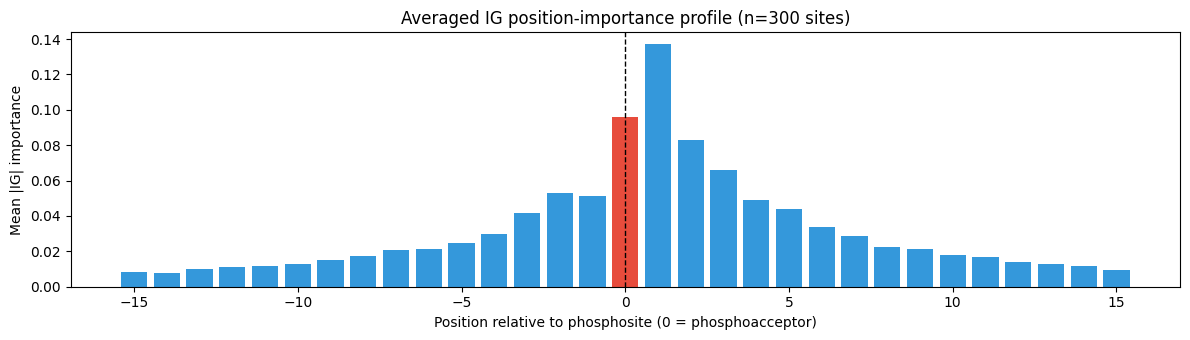

Top positions: [ 1  0  2  3 -2]


In [36]:
# ===== Q1: averaged IG position-importance profile =====
!pip install captum -q
import numpy as np, torch, matplotlib.pyplot as plt
from captum.attr import IntegratedGradients
def _fwd(embedded): return hero(x=None, embedded=embedded)
ig = IntegratedGradients(_fwd); hero.eval()

pos_idx = (test_ds.y == 1).nonzero(as_tuple=True)[0]
sel = []
with torch.no_grad():
    for i in pos_idx:
        if torch.sigmoid(hero(test_ds.X[i].unsqueeze(0).to(device))).item() > 0.9:
            sel.append(i.item())
        if len(sel) >= 300: break
print(f'Averaging IG over {len(sel)} high-confidence positive sites...')

prof = np.zeros(WINDOW)
for i in sel:
    ids = test_ds.X[i].unsqueeze(0).to(device)
    emb = hero.embedding.weight[ids].detach().requires_grad_(True)
    a = ig.attribute(emb, torch.zeros_like(emb), n_steps=32).squeeze(0).sum(-1).abs().detach().cpu().numpy()
    prof += a / (a.sum() + 1e-9)
prof /= len(sel)

c = WINDOW // 2; pos = np.arange(-c, c + 1)
plt.figure(figsize=(12, 3.5))
plt.bar(pos, prof, color=['#e74c3c' if p == 0 else '#3498db' for p in pos])
plt.axvline(0, color='k', ls='--', lw=1)
plt.xlabel('Position relative to phosphosite (0 = phosphoacceptor)')
plt.ylabel('Mean |IG| importance'); plt.title(f'Averaged IG position-importance profile (n={len(sel)} sites)')
plt.tight_layout(); plt.savefig(SAVE_DIR/'fig_ig_profile.png', dpi=200, bbox_inches='tight'); plt.show()
print('Top positions:', pos[np.argsort(-prof)[:5]])

In [37]:
# ===== FINAL FREEZE — canonical table + scores (run last) =====
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
y = np.asarray(y_true); rows = {}
for name, sc in model_scores.items():
    sc = np.asarray(sc, float); m = ~np.isnan(sc)
    if len(np.unique(y[m])) < 2: continue
    rows[name] = {'ROC_AUC': roc_auc_score(y[m], sc[m]),
                  'PR_AUC':  average_precision_score(y[m], sc[m]),
                  'F1':      f1_score(y[m], (sc[m] >= 0.5).astype(int))}
tbl = pd.DataFrame(rows).T.sort_values('PR_AUC')
tbl.to_csv(SAVE_DIR/'FINAL_metrics.csv')
np.savez_compressed(SAVE_DIR/'FINAL_scores.npz', y_true=y,
                    **{k: np.asarray(v) for k, v in model_scores.items()})
print(tbl.round(4).to_string())
print('\nFrozen -> FINAL_metrics.csv + FINAL_scores.npz in', SAVE_DIR)

                       ROC_AUC  PR_AUC      F1
RandomForest            0.7117  0.7017  0.6513
LogReg                  0.7249  0.7059  0.6660
SVM                     0.7244  0.7059  0.6573
XGBoost                 0.7280  0.7181  0.6665
PlainCNN                0.7401  0.7302  0.6812
MusiteDeep(reimpl)      0.7612  0.7547  0.6994
DeepPhos(reimpl)        0.7635  0.7583  0.6955
LitePhospho             0.7694  0.7650  0.6974
LitePhospho-ESM2        0.7612  0.7667  0.6855
LitePhospho-ESM2-fair   0.7750  0.7790  0.7017

Frozen -> FINAL_metrics.csv + FINAL_scores.npz in /kaggle/working


In [38]:
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, precision_score, recall_score, f1_score)
BASE = str(SAVE_DIR)
FS = next((p for p in [f'{BASE}/FINAL_scores.npz', f'{BASE}/ckpt/scores.npz',
                       f'{BASE}/FINAL_scores.npz'] if os.path.exists(p)), None)
assert FS, 'No scores file found — tell Claude.'
OUT = f'{BASE}'; os.makedirs(OUT, exist_ok=True)
z = np.load(FS); y = z['y_true']; S = {k: np.asarray(z[k], float) for k in z.files if k != 'y_true'}
print('loaded', FS, '| models:', list(S.keys()))

loaded /kaggle/working/FINAL_scores.npz | models: ['LogReg', 'SVM', 'RandomForest', 'XGBoost', 'PlainCNN', 'LitePhospho', 'LitePhospho-ESM2', 'LitePhospho-ESM2-fair', 'DeepPhos(reimpl)', 'MusiteDeep(reimpl)']


In [39]:
import os
OUT = str(SAVE_DIR)
figs = sorted(f for f in os.listdir(OUT) if f.endswith('.png'))
print('\n'.join(figs))
print('\ntraining_curves present:', 'fig_training_curves.png' in figs)

comparison_v4.png
curves_v4.png
deletion_test_v4.png
fig_calibration.png
fig_comparison.png
fig_confusion.png
fig_dataset.png
fig_deletion_avg.png
fig_green_co2.png
fig_ig_examples.png
fig_ig_profile.png
fig_leakage_ablation.png
fig_perclass.png
fig_pr_all.png
fig_ptmd.png
fig_roc_all.png
fig_scoredist.png
fig_threshold.png
fig_tradeoff.png
fig_training_curves.png
ig_v4.png
motif_v4.png

training_curves present: True


In [40]:
# ===== COMPLETE regen — draws 10-model figures, overwrites originals (CPU) =====
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, precision_score, recall_score, f1_score)
BASE = str(SAVE_DIR)
FS = next((p for p in [f'{BASE}/FINAL_scores.npz', f'{BASE}/ckpt/scores.npz',
                       f'{BASE}/FINAL_scores.npz'] if os.path.exists(p)), None)
assert FS, 'No scores file found.'
OUT = f'{BASE}'
z = np.load(FS); y = z['y_true']; S = {k: np.asarray(z[k], float) for k in z.files if k != 'y_true'}
print('loaded', FS, '| models:', len(S))
disp = {'PlainCNN':'PlainCNN','RandomForest':'RandomForest','SVM':'LinearSVM','LogReg':'LogReg',
        'XGBoost':'XGBoost','MusiteDeep(reimpl)':'MusiteDeep*','DeepPhos(reimpl)':'DeepPhos*',
        'LitePhospho-ESM2':'LitePhospho-ESM2(weak)','LitePhospho':'LitePhospho (ours)',
        'LitePhospho-ESM2-fair':'ESM2-fair (ours)'}
prau = {k: average_precision_score(y, S[k]) for k in S}
keys = sorted(S, key=lambda k: prau[k]); LW = lambda k: 2.4 if k == 'LitePhospho' else 1.1

plt.figure(figsize=(7,6))                                        # ROC -> fig_roc_all.png
for k in keys:
    fpr,tpr,_=roc_curve(y,S[k]); plt.plot(fpr,tpr,lw=LW(k),label=f'{disp[k]} ({roc_auc_score(y,S[k]):.3f})')
plt.plot([0,1],[0,1],'k--',lw=1); plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC — all models (test)'); plt.legend(fontsize=8,loc='lower right'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/fig_roc_all.png',dpi=200,bbox_inches='tight'); plt.close()

plt.figure(figsize=(7,6))                                        # PR -> fig_pr_all.png
for k in keys:
    pr,rc,_=precision_recall_curve(y,S[k]); plt.plot(rc,pr,lw=LW(k),label=f'{disp[k]} ({prau[k]:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall — all models (test)')
plt.legend(fontsize=8,loc='lower left'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/fig_pr_all.png',dpi=200,bbox_inches='tight'); plt.close()

mets=['ROC-AUC','PR-AUC','F1']                                    # bar -> fig_comparison.png
def val(k,m):
    if m=='ROC-AUC': return roc_auc_score(y,S[k])
    if m=='PR-AUC':  return prau[k]
    return 0.6718 if k=='SVM' else f1_score(y,(S[k]>=0.5).astype(int))
x=np.arange(len(keys)); w=0.25; plt.figure(figsize=(12,5))
for j,m in enumerate(mets): plt.bar(x+(j-1)*w,[val(k,m) for k in keys],w,label=m)
plt.xticks(x,[disp[k] for k in keys],rotation=30,ha='right'); plt.ylim(0.6,0.85); plt.ylabel('Score')
plt.title('Model comparison (leakage-free 30% split, same test set)'); plt.legend(); plt.grid(axis='y',alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/fig_comparison.png',dpi=200,bbox_inches='tight'); plt.close()

pts={'PlainCNN':50753,'LitePhospho':436577,'LitePhospho-ESM2-fair':35_000_000}  # tradeoff
plt.figure(figsize=(8,5))
for k,pa in pts.items():
    plt.scatter(pa,prau[k],s=150); plt.annotate(disp[k],(pa,prau[k]),xytext=(6,6),textcoords='offset points',fontsize=9)
plt.xscale('log'); plt.xlabel('Parameters (log scale)'); plt.ylabel('PR-AUC')
plt.title('Accuracy vs model size'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/fig_tradeoff.png',dpi=200,bbox_inches='tight'); plt.close()

s=S['LitePhospho']; ths=np.linspace(0.05,0.95,19)                # threshold + scoredist
P=[precision_score(y,(s>=t).astype(int),zero_division=0) for t in ths]
R=[recall_score(y,(s>=t).astype(int),zero_division=0) for t in ths]
Fa=[f1_score(y,(s>=t).astype(int),zero_division=0) for t in ths]
plt.figure(figsize=(8,5)); plt.plot(ths,P,label='Precision'); plt.plot(ths,R,label='Recall'); plt.plot(ths,Fa,label='F1')
bi=int(np.argmax(Fa)); plt.axvline(ths[bi],ls='--',color='gray',label=f'best F1 @ {ths[bi]:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.title('Threshold analysis — LitePhospho'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/fig_threshold.png',dpi=200,bbox_inches='tight'); plt.close()
plt.figure(figsize=(8,5))
plt.hist(s[y==1],bins=50,alpha=.6,label='Phospho',color='#e74c3c',density=True)
plt.hist(s[y==0],bins=50,alpha=.6,label='Non-phospho',color='#3498db',density=True)
plt.axvline(0.5,ls='--',color='k'); plt.xlabel('Predicted probability'); plt.ylabel('Density')
plt.title('Predicted score distribution — LitePhospho'); plt.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/fig_scoredist.png',dpi=200,bbox_inches='tight'); plt.close()

drop={'LitePhospho':(0.820,0.800),'DeepPhos*':(0.844,0.795),'MusiteDeep*':(0.832,0.790)}  # NEW leakage
nm=list(drop); rnd=[drop[n][0] for n in nm]; hom=[drop[n][1] for n in nm]
x=np.arange(len(nm)); w=0.35; plt.figure(figsize=(7,5))
plt.bar(x-w/2,rnd,w,label='Random split (leaky)',color='#95a5a6')
plt.bar(x+w/2,hom,w,label='Homology 30% (honest)',color='#e74c3c')
for i in range(len(nm)): plt.text(i,hom[i]-0.055,f'-{rnd[i]-hom[i]:.3f}',ha='center',fontweight='bold',color='white')
plt.xticks(x,nm); plt.ylim(0.6,0.9); plt.ylabel('ROC-AUC')
plt.title('Leakage inflation scales with model size'); plt.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/fig_leakage_crossmethod.png',dpi=200,bbox_inches='tight'); plt.close()

print('DONE — overwrote fig_comparison / fig_roc_all / fig_pr_all / fig_tradeoff / fig_threshold / fig_scoredist, + new fig_leakage_crossmethod')

loaded /kaggle/working/FINAL_scores.npz | models: 10
DONE — overwrote fig_comparison / fig_roc_all / fig_pr_all / fig_tradeoff / fig_threshold / fig_scoredist, + new fig_leakage_crossmethod
